# 📐 Layout Detection Benchmark
## DocLayoutYOLO (via Docling) vs NVIDIA Nemotron-Parse-v1.1

---

## 🏗️ Pipeline Overview

```
Upload PDF
     ↓
Render each page → PNG (150 DPI)
     ↓
     ├── Model A: DocLayoutYOLO (YOLO-based layout detector)
     │            via Docling  →  bboxes + class labels
     │
     └── Model B: NVIDIA Nemotron-Parse-v1.1 (ViT-H encoder + mBart decoder)
                  via HuggingFace  →  bboxes + class labels + markdown
                  ⚠️  Only runs on pages 7, 15, 17, 19, 25 (VRAM constraint on T4)
                  ⚠️  Input letterboxed to 896×896 square to preserve aspect ratio
     ↓
Side-by-side visualisation per page (Nemotron pages only)
     ↓
Comparison metrics: element counts, class distribution
```

---

| | DocLayoutYOLO | NVIDIA Nemotron-Parse-v1.1 |
|---|---|---|
| **Architecture** | YOLO-based object detector | ViT-H encoder + mBart decoder |
| **Parameters** | ~20M | ~885M |
| **Classes** | 11 (DocLayNet labels) | 11 (incl. Page-header/footer) |
| **Output** | Bounding boxes + classes | Bboxes + classes + text |
| **Speed** | Very fast (CPU-capable) | Slower (GPU strongly recommended) |
| **License** | MIT (via Docling) | NVIDIA Open Model License |

> **Note:** Run on Kaggle T4 GPU. Nemotron is limited to 5 pages due to VRAM.
> Input images are **letterbox-padded** to 896×896 (not stretched) so bbox coordinates
> are geometrically correct after inverting the transform back to original pixel space.

## Cell 1 — Install Dependencies

In [1]:
import subprocess

def run(cmd, desc=''):
    if desc:
        print(f'  {desc}...')
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  STDERR: {r.stderr[-300:]}')
    return r.returncode

# ── DocLayoutYOLO via Docling ─────────────────────────────────
print('📦 Installing Docling (DocLayoutYOLO + TableFormer)...')
run('pip install docling -q', 'docling')

# ── NVIDIA Nemotron-Parse-v1.1 ────────────────────────────────
print('\n📦 Installing Nemotron-Parse dependencies...')
run('pip install "transformers==4.51.3" -q',  'transformers 4.51.3')
run('pip install "accelerate==1.12.0" -q',    'accelerate')
run('pip install "albumentations==2.0.8" -q', 'albumentations')
run('pip install "timm==1.0.22" -q',          'timm')
run('pip install open_clip_torch -q',         'open_clip_torch')

# ── Utilities ─────────────────────────────────────────────────
print('\n📦 Installing utilities...')
run('pip install pymupdf pillow pandas matplotlib seaborn -q', 'utilities')

print('\n✅ All dependencies installed')
print('   Model A : Docling (DocLayoutYOLO)')
print('   Model B : NVIDIA Nemotron-Parse-v1.1 (HuggingFace)')

📦 Installing Docling (DocLayoutYOLO + TableFormer)...
  docling...

📦 Installing Nemotron-Parse dependencies...
  transformers 4.51.3...
  accelerate...
  albumentations...
  timm...
  open_clip_torch...

📦 Installing utilities...
  utilities...

✅ All dependencies installed
   Model A : Docling (DocLayoutYOLO)
   Model B : NVIDIA Nemotron-Parse-v1.1 (HuggingFace)


## Cell 2 — Configuration & Imports

In [2]:
import os, re, json, glob, time, warnings
import fitz
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont
from collections import defaultdict, Counter
from IPython.display import display as ipy_display
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────
CONFIG = {
    'render_dpi'      : 150,
    'max_pages'       : 30,
    'min_bbox_area'   : 100,
    'nemotron_model'  : 'nvidia/NVIDIA-Nemotron-Parse-v1.1',
    'nemotron_pages'  : [7, 15, 17, 19, 25],
    'nemotron_infer_size' : 896,   # letterbox long-side; C-RADIOv2-H native patch size
    'output_dir'      : '/kaggle/working/layout_output',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Config ready')
print(f'   Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU     : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'   VRAM    : {vram:.1f} GB')
print(f'   DocLayoutYOLO pages : all up to {CONFIG["max_pages"]}')
print(f'   Nemotron pages      : {CONFIG["nemotron_pages"]}')
print(f'   Nemotron infer size : {CONFIG["nemotron_infer_size"]}×{CONFIG["nemotron_infer_size"]} (letterboxed square)')

# ── Colour maps ───────────────────────────────────────────────
DOCLING_COLORS = {
    'title'          : '#e63946',
    'section_header' : '#ff6b35',
    'text'           : '#457b9d',
    'list_item'      : '#2a9d8f',
    'table'          : '#e9c46a',
    'picture'        : '#f4a261',
    'caption'        : '#8ecae6',
    'footnote'       : '#a8dadc',
    'formula'        : '#6d6875',
    'page_header'    : '#b5838d',
    'page_footer'    : '#e5989b',
}

# Actual class names produced by Nemotron-Parse v1.1
# (discovered from raw output inspection — model card docs are wrong)
NEMOTRON_COLORS = {
    'Title'          : '#e63946',
    'Text'           : '#457b9d',
    'Table'          : '#e9c46a',
    'Picture'        : '#f4a261',
    'Caption'        : '#8ecae6',
    'Footnote'       : '#a8dadc',
    'Formula'        : '#6d6875',
    'List-item'      : '#2a9d8f',
    'Section-header' : '#ff6b35',
    'Page-header'    : '#b5838d',
    'Page-footer'    : '#e5989b',
}

DEFAULT_COLOR = '#888888'
print('\n✅ Colour maps ready')

✅ Config ready
   Device  : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   DocLayoutYOLO pages : all up to 30
   Nemotron pages      : [7, 15, 17, 19, 25]
   Nemotron infer size : 896×896 (letterboxed square)

✅ Colour maps ready


## Cell 3 — Upload PDF

In [3]:
# On Kaggle: attach your PDF as a dataset
# Notebook Settings → Add Data → upload your PDF
# It will appear at /kaggle/input/your-dataset-name/

pdf_paths = glob.glob('/kaggle/input/datasets/anikpanja/medical-demo/Medical_004_demo_30p.pdf', recursive=True)
if not pdf_paths:
    pdf_paths = glob.glob('./*.pdf')

if not pdf_paths:
    print('⚠️  No PDF found.')
    print('   → Attach your PDF as a Kaggle dataset')
    print('   → Or place PDF in the same folder as this notebook')
else:
    PDF_PATH = pdf_paths[0]
    doc      = fitz.open(PDF_PATH)
    N_PAGES  = len(doc)
    doc.close()
    size_kb  = os.path.getsize(PDF_PATH) // 1024
    print(f'✅ PDF loaded: {os.path.basename(PDF_PATH)}')
    print(f'   Pages : {N_PAGES}')
    print(f'   Size  : {size_kb} KB')
    pages_to_process = list(range(1, min(N_PAGES, CONFIG['max_pages']) + 1))
    nemotron_pages   = [p for p in CONFIG['nemotron_pages'] if p <= N_PAGES]
    print(f'   DocLayoutYOLO pages : {pages_to_process}')
    print(f'   Nemotron pages      : {nemotron_pages}')

✅ PDF loaded: Medical_004_demo_30p.pdf
   Pages : 30
   Size  : 6284 KB
   DocLayoutYOLO pages : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
   Nemotron pages      : [7, 15, 17, 19, 25]


## Cell 4 — Render PDF Pages to Images

In [4]:
def render_page(pdf_path, page_num_1idx, dpi=150):
    """Render a PDF page to PIL Image at given DPI."""
    doc   = fitz.open(pdf_path)
    page  = doc[page_num_1idx - 1]
    scale = dpi / 72
    mat   = fitz.Matrix(scale, scale)
    pix   = page.get_pixmap(matrix=mat, alpha=False)
    img   = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
    doc.close()
    return img

page_images = {}   # { page_num: PIL Image }

print(f'🖼️  Rendering {len(pages_to_process)} pages at {CONFIG["render_dpi"]} DPI...\n')
for pg in pages_to_process:
    img = render_page(PDF_PATH, pg, dpi=CONFIG['render_dpi'])
    page_images[pg] = img
    save_path = f"{CONFIG['output_dir']}/page_{pg:02d}_original.png"
    img.save(save_path)
    print(f'   Page {pg}: {img.width}×{img.height}px  → saved')

print(f'\n✅ {len(page_images)} pages rendered and cached')

🖼️  Rendering 30 pages at 150 DPI...

   Page 1: 1275×1650px  → saved
   Page 2: 1275×1650px  → saved
   Page 3: 1275×1650px  → saved
   Page 4: 1275×1650px  → saved
   Page 5: 1275×1650px  → saved
   Page 6: 1275×1650px  → saved
   Page 7: 1275×1650px  → saved
   Page 8: 1275×1650px  → saved
   Page 9: 1275×1650px  → saved
   Page 10: 1275×1650px  → saved
   Page 11: 1275×1650px  → saved
   Page 12: 1275×1650px  → saved
   Page 13: 1275×1650px  → saved
   Page 14: 1275×1650px  → saved
   Page 15: 1275×1650px  → saved
   Page 16: 1275×1650px  → saved
   Page 17: 1275×1650px  → saved
   Page 18: 1275×1650px  → saved
   Page 19: 1275×1650px  → saved
   Page 20: 1275×1650px  → saved
   Page 21: 1275×1650px  → saved
   Page 22: 1275×1650px  → saved
   Page 23: 1275×1650px  → saved
   Page 24: 1275×1650px  → saved
   Page 25: 1275×1650px  → saved
   Page 26: 1275×1650px  → saved
   Page 27: 1275×1650px  → saved
   Page 28: 1275×1650px  → saved
   Page 29: 1275×1650px  → saved
   Page 30: 12

## Cell 5 — Model A: DocLayoutYOLO via Docling

In [5]:
# ── MODEL A: DocLayoutYOLO (YOLO backbone) ────────────────────
# Architecture : YOLO-based detector trained on DocLayNet (150k pages, 11 classes)
# Classes      : title, section_header, text, list_item, table,
#                picture, caption, footnote, formula, page_header, page_footer
# Speed        : ~0.3s/page on CPU, ~0.1s on GPU
# Access       : via Docling Python API (MIT license)

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

print('='*60)
print('  MODEL A — DocLayoutYOLO (via Docling)')
print('  YOLO backbone | trained on DocLayNet | 11 classes')
print('='*60)

pipeline_options = PdfPipelineOptions()
pipeline_options.do_table_structure = True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

print('\n🔍 Running DocLayoutYOLO layout detection...')
t0      = time.time()
result  = converter.convert(PDF_PATH)
doc_obj = result.document
elapsed = time.time() - t0
print(f'   ✅ Done in {elapsed:.1f}s')


def get_docling_elements(doc_obj, page_images, pages_to_process):
    results = defaultdict(list)
    for item, _ in doc_obj.iterate_items():
        if not hasattr(item, 'prov') or not item.prov:
            continue
        prov   = item.prov[0]
        pg_num = prov.page_no
        if pg_num not in pages_to_process:
            continue
        bbox  = prov.bbox
        label = type(item).__name__.lower().replace('item', '').replace('docling', '')
        label_map = {
            'text'               : 'text',
            'sectionheader'      : 'section_header',
            'listitem'           : 'list_item',
            'table'              : 'table',
            'picture'            : 'picture',
            'figurecaption'      : 'caption',
            'footnote'           : 'footnote',
            'formula'            : 'formula',
            'pageheader'         : 'page_header',
            'pagefooter'         : 'page_footer',
            'title'              : 'title',
            'keyvalueitem'       : 'text',
            'inlinemathexpression': 'formula',
        }
        label = label_map.get(label, label)
        img   = page_images.get(pg_num)
        if img is None:
            continue
        try:
            page_info = doc_obj.pages.get(pg_num)
            if page_info and page_info.size:
                pw_pt = page_info.size.width
                ph_pt = page_info.size.height
            else:
                pw_pt, ph_pt = 595, 842
            pw_px = img.width
            ph_px = img.height
            x0_px = (bbox.l / pw_pt) * pw_px
            y0_px = ((ph_pt - bbox.t) / ph_pt) * ph_px
            x1_px = (bbox.r / pw_pt) * pw_px
            y1_px = ((ph_pt - bbox.b) / ph_pt) * ph_px
            x0_px, x1_px = min(x0_px, x1_px), max(x0_px, x1_px)
            y0_px, y1_px = min(y0_px, y1_px), max(y0_px, y1_px)
            area = (x1_px - x0_px) * (y1_px - y0_px)
            if area < CONFIG['min_bbox_area']:
                continue
            text = ''
            try:
                text = item.text if hasattr(item, 'text') and item.text else ''
            except Exception:
                pass
            results[pg_num].append({
                'type'  : label,
                'bbox'  : [x0_px, y0_px, x1_px, y1_px],
                'text'  : str(text)[:200],
                'model' : 'DocLayoutYOLO',
            })
        except Exception:
            continue
    return results


docling_results = get_docling_elements(doc_obj, page_images, pages_to_process)

print('\n📊 DocLayoutYOLO detection summary:')
total_docling = 0
for pg in pages_to_process:
    els          = docling_results.get(pg, [])
    total_docling += len(els)
    counts       = Counter(e['type'] for e in els)
    print(f'   Page {pg}: {len(els)} elements — {dict(counts)}')
print(f'   TOTAL: {total_docling} elements')

2026-06-08 05:22:51.977716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780896172.186412      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780896172.259562      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780896172.798473      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780896172.798514      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780896172.798517      58 computation_placer.cc:177] computation placer alr

  MODEL A — DocLayoutYOLO (via Docling)
  YOLO backbone | trained on DocLayNet | 11 classes

🔍 Running DocLayoutYOLO layout detection...
   ✅ Done in 51.4s

📊 DocLayoutYOLO detection summary:
   Page 1: 4 elements — {'picture': 3, 'section_header': 1}
   Page 2: 4 elements — {'section_header': 1, 'table': 1, 'text': 1, 'picture': 1}
   Page 3: 4 elements — {'table': 1, 'text': 2, 'picture': 1}
   Page 4: 3 elements — {'table': 1, 'text': 1, 'picture': 1}
   Page 5: 4 elements — {'table': 1, 'text': 2, 'picture': 1}
   Page 6: 0 elements — {}
   Page 7: 10 elements — {'section_header': 1, 'text': 7, 'picture': 2}
   Page 8: 13 elements — {'section_header': 1, 'text': 11, 'picture': 1}
   Page 9: 17 elements — {'section_header': 6, 'text': 10, 'picture': 1}
   Page 10: 17 elements — {'section_header': 6, 'text': 10, 'picture': 1}
   Page 11: 26 elements — {'section_header': 5, 'text': 13, 'list': 7, 'picture': 1}
   Page 12: 4 elements — {'section_header': 2, 'table': 1, 'picture': 1}
  

## Cell 6 — Model B: NVIDIA Nemotron-Parse-v1.1

In [14]:
# ── MODEL B: NVIDIA Nemotron-Parse-v1.1 ──────────────────────
# Architecture  : ViT-H encoder (C-RADIO) + 1D conv adapter + mBart decoder
# Parameters    : ~885M
# Output format : <x_L><y_T>text<x_R><y_B><class_LABEL>
#                 Coords are 0.0-1.0 normalised relative to the
#                 PADDED tensor (1648×2048), NOT the original image.
#
# ✅  Fix: processor internally centre-pads original image to 1648×2048.
#          We invert that padding offset to get correct original pixel coords.
#          No resizing needed — pass original PIL image directly.
#
# ⚠️  Page limit: Only CONFIG['nemotron_pages'] processed (T4 VRAM limit).

import os, importlib, subprocess as _sp, re
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

if importlib.util.find_spec('open_clip') is None:
    print('⚙️  Installing open_clip_torch...')
    _sp.run('pip install open_clip_torch -q', shell=True, check=True)
    print('   ✅ Done')
else:
    print('✅ open_clip available')

from transformers import AutoModel, AutoProcessor, AutoTokenizer, AutoConfig, GenerationConfig

print('='*60)
print('  MODEL B — NVIDIA Nemotron-Parse-v1.1')
print('  ViT-H encoder + mBart decoder | 885M params')
print('='*60)

MODEL_PATH = CONFIG['nemotron_model']
print(f'\nLoading from {MODEL_PATH}...\n')

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

t0 = time.time()
nemo_model = AutoModel.from_pretrained(
    MODEL_PATH,
    trust_remote_code = True,
    torch_dtype       = torch.float16,
    low_cpu_mem_usage = True,
).to(DEVICE).eval()

try:
    nemo_model = torch.compile(nemo_model, mode='reduce-overhead')
    print('   ✅ torch.compile applied')
except Exception:
    pass

nemo_tokenizer  = AutoTokenizer.from_pretrained(MODEL_PATH)
nemo_processor  = AutoProcessor.from_pretrained(MODEL_PATH, trust_remote_code=True)
nemo_gen_config = GenerationConfig.from_pretrained(MODEL_PATH, trust_remote_code=True)
nemo_gen_config.max_new_tokens = 1024

print(f'✅ Nemotron-Parse loaded in {time.time()-t0:.1f}s')
if DEVICE == 'cuda':
    print(f'   GPU memory allocated : {torch.cuda.memory_allocated()/1e9:.1f} GB')
    print(f'   GPU memory reserved  : {torch.cuda.memory_reserved()/1e9:.1f} GB')

NEMOTRON_PAGES = [p for p in CONFIG['nemotron_pages'] if p in page_images]
print(f'\n📋 Nemotron will process pages: {NEMOTRON_PAGES}')

# ── Processor pad dimensions (confirmed from processor config) ─
# NemotronParseImageProcessor always centre-pads input to 1648×2048.
# Coords in output are 0-1 normalised relative to this padded tensor.
PROC_W = 1648
PROC_H = 2048

# ── Output format parser ──────────────────────────────────────
# Actual v1.1 format (confirmed from raw output inspection):
#   <x_LEFT><y_TOP>text content<x_RIGHT><y_BOTTOM><class_LABEL>
#   Coords: 0.0-1.0 normalised fractions of PROC_W × PROC_H
BLOCK_PATTERN = re.compile(
    r'<x_([0-9.]+)><y_([0-9.]+)>'   # top-left  (x_L, y_T)
    r'(.*?)'                          # text content
    r'<x_([0-9.]+)><y_([0-9.]+)>'   # bottom-right (x_R, y_B)
    r'<class_([^>]+)>',              # class label
    re.DOTALL
)


def run_nemotron_on_page(pil_image):
    """
    Pass original PIL image directly — no resizing needed.

    The processor centre-pads the image to PROC_W×PROC_H internally.
    Padding added on each side:
        pad_x = (PROC_W - orig_w) / 2
        pad_y = (PROC_H - orig_h) / 2

    To recover original pixel coords from normalised output coords:
        padded_px  = norm * PROC_size
        content_px = padded_px - pad_offset
        (no further scaling since content was not resized, only padded)
    """
    orig_w, orig_h = pil_image.size

    # Padding the processor adds on each side (centre-pad)
    pad_x = (PROC_W - orig_w) / 2   # e.g. (1648 - 1275) / 2 = 186.5
    pad_y = (PROC_H - orig_h) / 2   # e.g. (2048 - 1650) / 2 = 199.0

    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    task_prompt = '</s><s><predict_bbox><predict_classes><output_markdown>'

    inputs = nemo_processor(
        images             = [pil_image],   # original image, no resize
        text               = task_prompt,
        return_tensors     = 'pt',
        add_special_tokens = False,
    ).to(DEVICE)

    with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
        outputs = nemo_model.generate(
            **inputs,
            generation_config = nemo_gen_config,
        )

    generated_text = nemo_processor.batch_decode(
        outputs, skip_special_tokens=True
    )[0]

    del inputs, outputs
    torch.cuda.empty_cache()

    # ── Invert centre-pad transform → original pixel coords ───
    dets = []
    for match in BLOCK_PATTERN.finditer(generated_text):
        x0_n  = float(match.group(1))
        y0_n  = float(match.group(2))
        text  = match.group(3).strip()
        x1_n  = float(match.group(4))
        y1_n  = float(match.group(5))
        label = match.group(6).strip()

        # Step 1: normalised → padded tensor pixel coords
        px0 = x0_n * PROC_W;  py0 = y0_n * PROC_H
        px1 = x1_n * PROC_W;  py1 = y1_n * PROC_H

        # Step 2: subtract centre-pad offset → original image pixel coords
        x0 = px0 - pad_x;  y0 = py0 - pad_y
        x1 = px1 - pad_x;  y1 = py1 - pad_y

        # Ensure correct corner order (model occasionally swaps)
        x0, x1 = min(x0, x1), max(x0, x1)
        y0, y1 = min(y0, y1), max(y0, y1)

        # Clamp to original image bounds
        x0 = max(0.0, min(float(orig_w), x0))
        y0 = max(0.0, min(float(orig_h), y0))
        x1 = max(0.0, min(float(orig_w), x1))
        y1 = max(0.0, min(float(orig_h), y1))

        if (x1 - x0) * (y1 - y0) < CONFIG['min_bbox_area']:
            continue

        dets.append({
            'type' : label,
            'bbox' : [x0, y0, x1, y1],
            'text' : text[:200],
            'model': 'Nemotron',
        })

    return dets, generated_text


# ── Run on target pages ───────────────────────────────────────
nemotron_results  = {pg: [] for pg in pages_to_process}
nemotron_raw_text = {pg: '' for pg in pages_to_process}

print(f'\n🔍 Running Nemotron-Parse on {len(NEMOTRON_PAGES)} pages')
print(f'   Processor pad: {PROC_W}×{PROC_H} centre-pad (no resize)\n')

for pg in NEMOTRON_PAGES:
    img = page_images[pg]
    orig_w, orig_h = img.size
    pad_x = (PROC_W - orig_w) / 2
    pad_y = (PROC_H - orig_h) / 2
    print(f'   Page {pg} ({orig_w}×{orig_h}px) → pad_x={pad_x:.1f}, pad_y={pad_y:.1f}')
    t0 = time.time()
    try:
        dets, raw = run_nemotron_on_page(img)
        nemotron_results[pg]  = dets
        nemotron_raw_text[pg] = raw
        counts = Counter(d['type'] for d in dets)
        print(f'   ✅ {len(dets)} elements in {time.time()-t0:.1f}s — {dict(counts)}')
    except torch.cuda.OutOfMemoryError as e:
        torch.cuda.empty_cache()
        print(f'   ❌ OOM on page {pg}: {e}')
    except Exception as e:
        print(f'   ❌ Error on page {pg}: {e}')

total_nemo = sum(len(nemotron_results[p]) for p in NEMOTRON_PAGES)
print(f'\n✅ Nemotron done — {total_nemo} elements across pages {NEMOTRON_PAGES}')
print(f'   (Remaining pages have empty Nemotron results — DocLayoutYOLO ran on all pages)')

✅ open_clip available
  MODEL B — NVIDIA Nemotron-Parse-v1.1
  ViT-H encoder + mBart decoder | 885M params

Loading from nvidia/NVIDIA-Nemotron-Parse-v1.1...



Some weights of the model checkpoint at nvidia/NVIDIA-Nemotron-Parse-v1.1 were not used when initializing NemotronParseForConditionalGeneration: ['decoder.embed_positions.weight']
- This IS expected if you are initializing NemotronParseForConditionalGeneration from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NemotronParseForConditionalGeneration from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


   ✅ torch.compile applied
✅ Nemotron-Parse loaded in 4.2s
   GPU memory allocated : 3.7 GB
   GPU memory reserved  : 4.5 GB

📋 Nemotron will process pages: [7, 15, 17, 19, 25]

🔍 Running Nemotron-Parse on 5 pages
   Processor pad: 1648×2048 centre-pad (no resize)

   Page 7 (1275×1650px) → pad_x=186.5, pad_y=199.0
   ✅ 10 elements in 12.0s — {'Page-header': 1, 'Title': 1, 'Section-header': 1, 'Text': 5, 'Page-footer': 1, 'Picture': 1}
   Page 15 (1275×1650px) → pad_x=186.5, pad_y=199.0
   ✅ 18 elements in 19.3s — {'Page-header': 1, 'Section-header': 4, 'List-item': 12, 'Page-footer': 1}
   Page 17 (1275×1650px) → pad_x=186.5, pad_y=199.0
   ✅ 4 elements in 18.9s — {'Title': 1, 'Section-header': 1, 'Page-footer': 1, 'Table': 1}
   Page 19 (1275×1650px) → pad_x=186.5, pad_y=199.0
   ✅ 13 elements in 7.5s — {'Page-header': 1, 'Page-footer': 1, 'Picture': 7, 'Caption': 4}
   Page 25 (1275×1650px) → pad_x=186.5, pad_y=199.0
   ✅ 15 elements in 12.5s — {'Title': 1, 'Section-header': 1, 'Pag

In [15]:
# ── DEBUG CELL — bbox coordinate sanity check ─────────────────
# Run this right after Cell 6. Checks one page end-to-end:
# letterbox transform, raw output coords, and final mapped coords.

DEBUG_PAGE = NEMOTRON_PAGES[0]   # use first Nemotron page (e.g. page 7)
img        = page_images[DEBUG_PAGE]
orig_w, orig_h = img.size

print(f'═'*65)
print(f'  DEBUG — Page {DEBUG_PAGE}')
print(f'═'*65)

# ── Step 1: Reproduce the letterbox transform ─────────────────
size  = INFER_SIZE
w, h  = img.size
scale = size / max(w, h)
new_w = int(w * scale)
new_h = int(h * scale)
x_off = (size - new_w) // 2
y_off = (size - new_h) // 2

print(f'\n[Step 1] Original image   : {orig_w} × {orig_h} px')
print(f'         Scale factor     : {scale:.6f}')
print(f'         Resized to       : {new_w} × {new_h} px')
print(f'         Canvas size      : {size} × {size} px')
print(f'         Padding offset   : x_off={x_off}, y_off={y_off}')
print(f'         Content region   : x=[{x_off}, {x_off+new_w}]  y=[{y_off}, {y_off+new_h}]')

# ── Step 2: Show raw Nemotron output for this page ─────────────
raw = nemotron_raw_text.get(DEBUG_PAGE, '')
print(f'\n[Step 2] Raw output length : {len(raw)} chars')
print(f'         First 400 chars  :')
print(repr(raw[:400]))

# ── Step 3: Show first 5 parsed detections IN SQUARE space ─────
import re
BLOCK_PATTERN_DBG = re.compile(
    r'<x_([0-9.]+)><y_([0-9.]+)>(.*?)<x_([0-9.]+)><y_([0-9.]+)><class_([^>]+)>',
    re.DOTALL
)
matches = list(BLOCK_PATTERN_DBG.finditer(raw))
print(f'\n[Step 3] Total raw matches : {len(matches)}')
print(f'         First 5 detections in 896×896 SQUARE pixel space:')
for i, m in enumerate(matches[:5]):
    x0n, y0n, x1n, y1n = float(m.group(1)), float(m.group(2)), float(m.group(4)), float(m.group(5))
    label = m.group(6)
    # coords in square pixel space
    sq_x0 = x0n * size
    sq_y0 = y0n * size
    sq_x1 = x1n * size
    sq_y1 = y1n * size
    print(f'         [{i}] {label:20s}  norm=({x0n:.4f},{y0n:.4f},{x1n:.4f},{y1n:.4f})')
    print(f'              square px : ({sq_x0:.1f}, {sq_y0:.1f}, {sq_x1:.1f}, {sq_y1:.1f})')

# ── Step 4: Show inversion for first 5 detections ─────────────
print(f'\n[Step 4] After inverting letterbox → original pixel space:')
print(f'         Formula: orig_x = (sq_x - x_off={x_off}) / scale={scale:.4f}')
print(f'         Formula: orig_y = (sq_y - y_off={y_off}) / scale={scale:.4f}')
for i, m in enumerate(matches[:5]):
    x0n, y0n, x1n, y1n = float(m.group(1)), float(m.group(2)), float(m.group(4)), float(m.group(5))
    label = m.group(6)
    sq_x0 = x0n * size;  sq_y0 = y0n * size
    sq_x1 = x1n * size;  sq_y1 = y1n * size
    ox0 = (sq_x0 - x_off) / scale
    oy0 = (sq_y0 - y_off) / scale
    ox1 = (sq_x1 - x_off) / scale
    oy1 = (sq_y1 - y_off) / scale
    print(f'         [{i}] {label:20s}  orig px: ({ox0:.1f}, {oy0:.1f}, {ox1:.1f}, {oy1:.1f})')
    in_bounds = (0 <= ox0 <= orig_w and 0 <= oy0 <= orig_h and
                 0 <= ox1 <= orig_w and 0 <= oy1 <= orig_h)
    print(f'              in bounds [{orig_w}×{orig_h}]: {in_bounds}')

# ── Step 5: Show what Cell 6 actually stored ───────────────────
stored = nemotron_results.get(DEBUG_PAGE, [])
print(f'\n[Step 5] Stored detections for page {DEBUG_PAGE}: {len(stored)} total')
print(f'         First 5 stored bboxes (should match Step 4):')
for i, d in enumerate(stored[:5]):
    print(f'         [{i}] {d["type"]:20s}  bbox={[round(v,1) for v in d["bbox"]]}')

# ── Step 6: Check if any bbox exceeds page bounds ─────────────
print(f'\n[Step 6] Bounds check on ALL stored detections:')
out_x = [d for d in stored if d['bbox'][2] > orig_w or d['bbox'][0] < 0]
out_y = [d for d in stored if d['bbox'][3] > orig_h or d['bbox'][1] < 0]
ok    = [d for d in stored if d['bbox'][2] <= orig_w and d['bbox'][3] <= orig_h
                            and d['bbox'][0] >= 0 and d['bbox'][1] >= 0]
print(f'         In bounds  : {len(ok)}')
print(f'         Out of X   : {len(out_x)}')
print(f'         Out of Y   : {len(out_y)}')

# ── Step 7: Coverage check — do bboxes span the full page? ────
if stored:
    all_x0 = min(d['bbox'][0] for d in stored)
    all_y0 = min(d['bbox'][1] for d in stored)
    all_x1 = max(d['bbox'][2] for d in stored)
    all_y1 = max(d['bbox'][3] for d in stored)
    print(f'\n[Step 7] Bbox coverage across page {DEBUG_PAGE}:')
    print(f'         X range : {all_x0:.1f} → {all_x1:.1f}  (page width  = {orig_w})')
    print(f'         Y range : {all_y0:.1f} → {all_y1:.1f}  (page height = {orig_h})')
    print(f'         X coverage : {(all_x1-all_x0)/orig_w*100:.1f}% of page width')
    print(f'         Y coverage : {(all_y1-all_y0)/orig_h*100:.1f}% of page height')
    print(f'\n  ⚠️  If X/Y coverage << 100%, bboxes are still clustered — scaling bug persists.')
    print(f'  ✅  If X/Y coverage ≈ full page, the fix is working.')

═════════════════════════════════════════════════════════════════
  DEBUG — Page 7
═════════════════════════════════════════════════════════════════

[Step 1] Original image   : 1275 × 1650 px
         Scale factor     : 0.543030
         Resized to       : 692 × 896 px
         Canvas size      : 896 × 896 px
         Padding offset   : x_off=102, y_off=0
         Content region   : x=[102, 794]  y=[0, 896]

[Step 2] Raw output length : 2340 chars
         First 400 chars  :
'<x_0.8613><y_0.1398>GENERAL INFORMATION<x_0.876><y_0.2594><class_Page-header>\n\n<x_0.1777><y_0.1531># PILLING<sup>®</sup> AND KMEDIC<sup>®</sup> SURGICAL INSTRUMENTS<x_0.8057><y_0.1734><class_Title>\n\n<x_0.1787><y_0.1766>Quality that builds confidence<x_0.4482><y_0.1938><class_Section-header>\n\n<x_0.1797><y_0.2406>For nearly 200 years, Pilling<sup>®</sup> quality instruments have been provided to sur'

[Step 3] Total raw matches : 10
         First 5 detections in 896×896 SQUARE pixel space:
         [0] Page-

## Cell 7 — Side-by-Side Visualisation (Nemotron pages only)

🗺️  Rendering side-by-side comparisons for pages: [7, 15, 17, 19, 25]



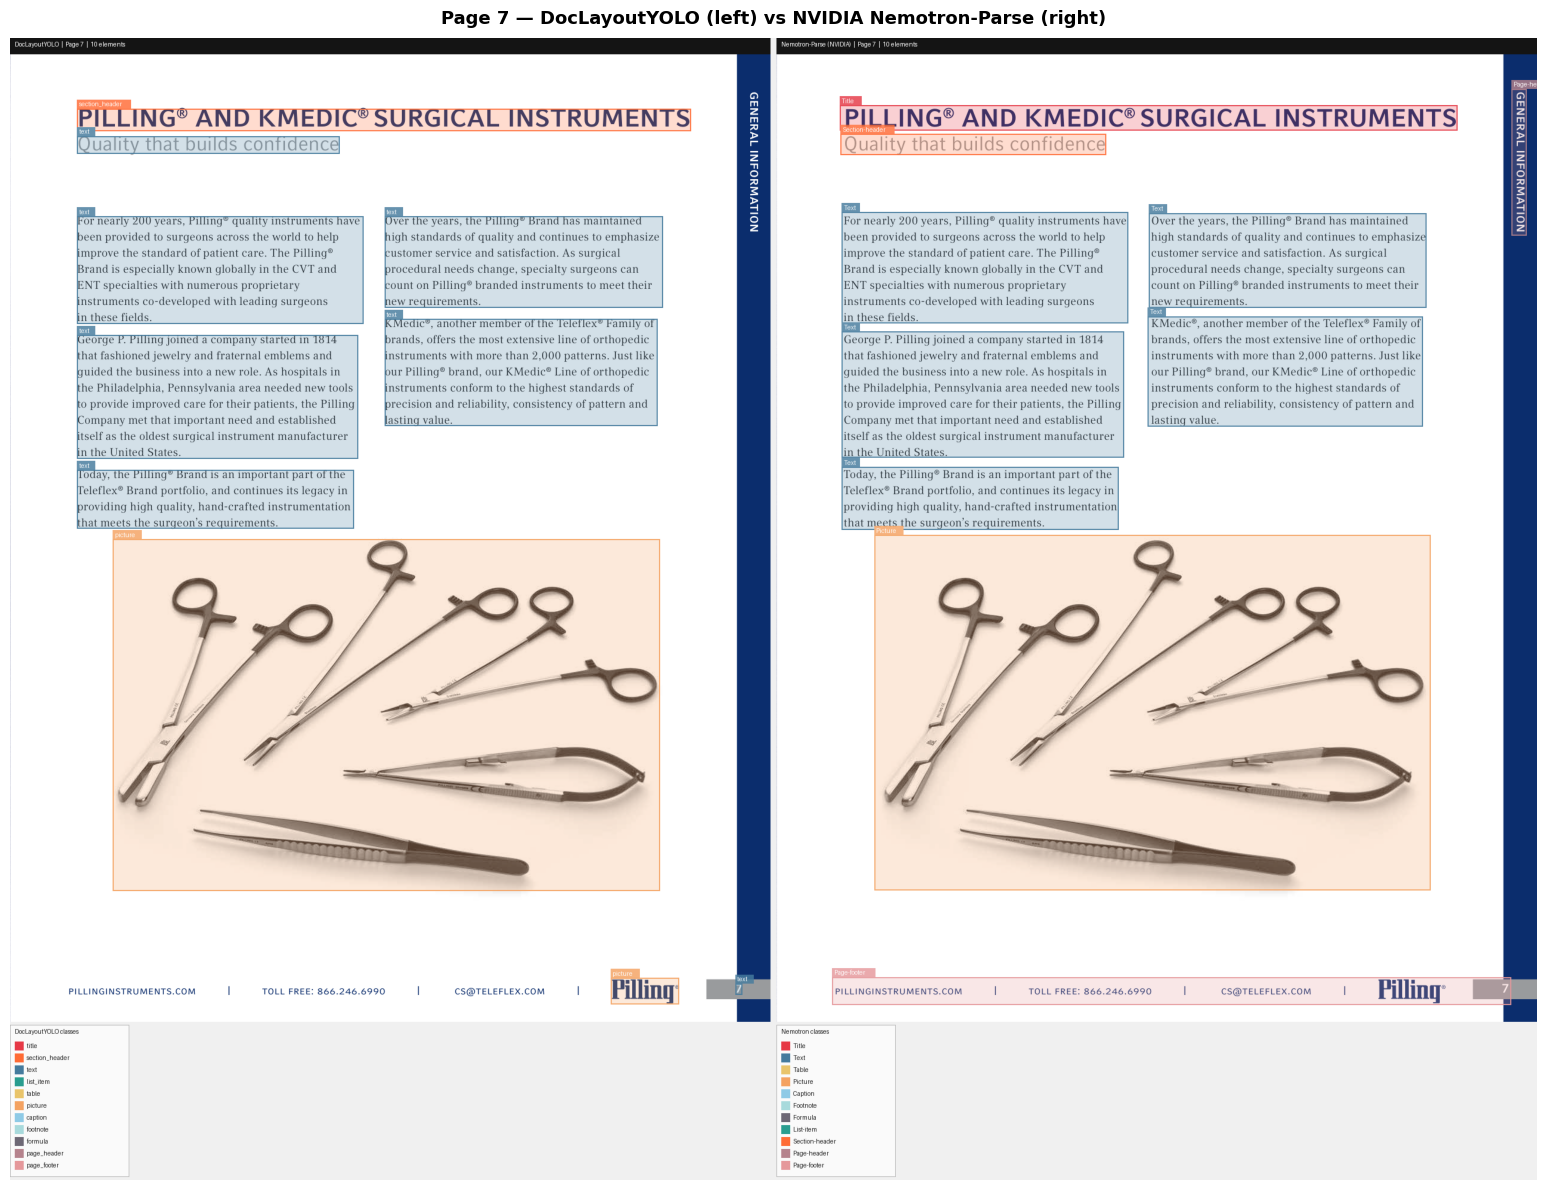

   💾 Page 7 saved → /kaggle/working/layout_output/page_07_comparison.png


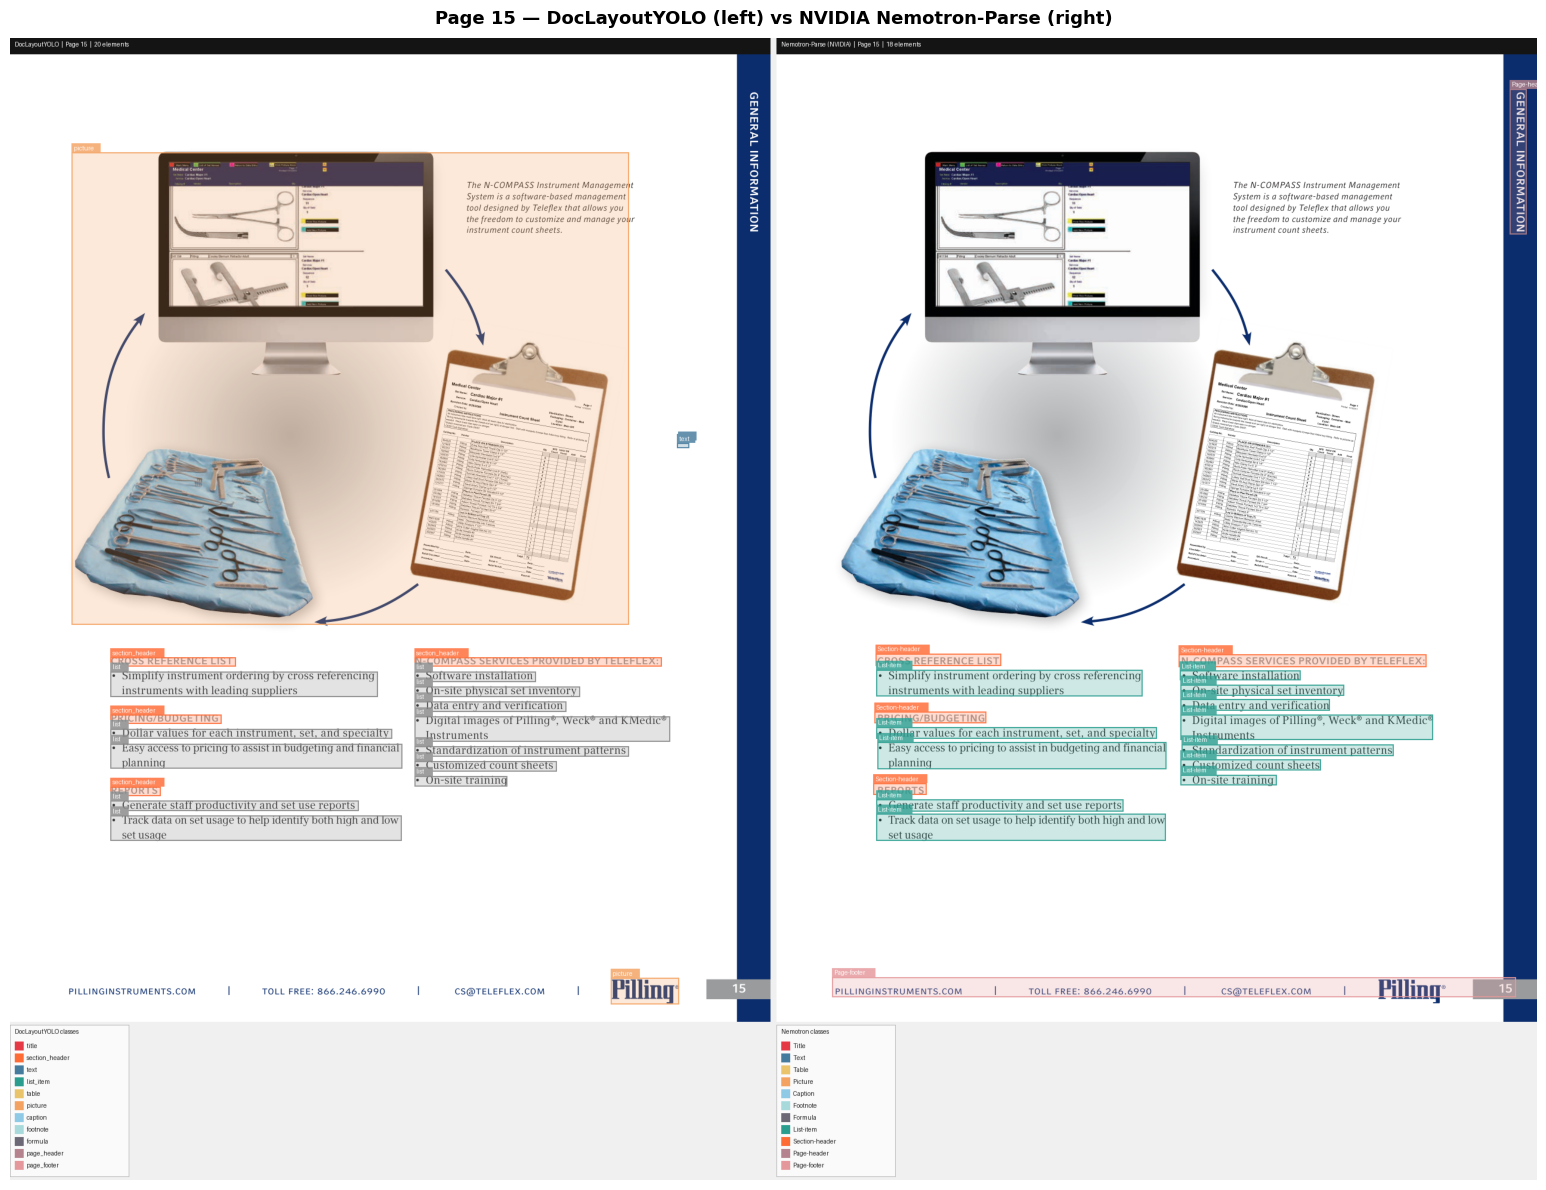

   💾 Page 15 saved → /kaggle/working/layout_output/page_15_comparison.png


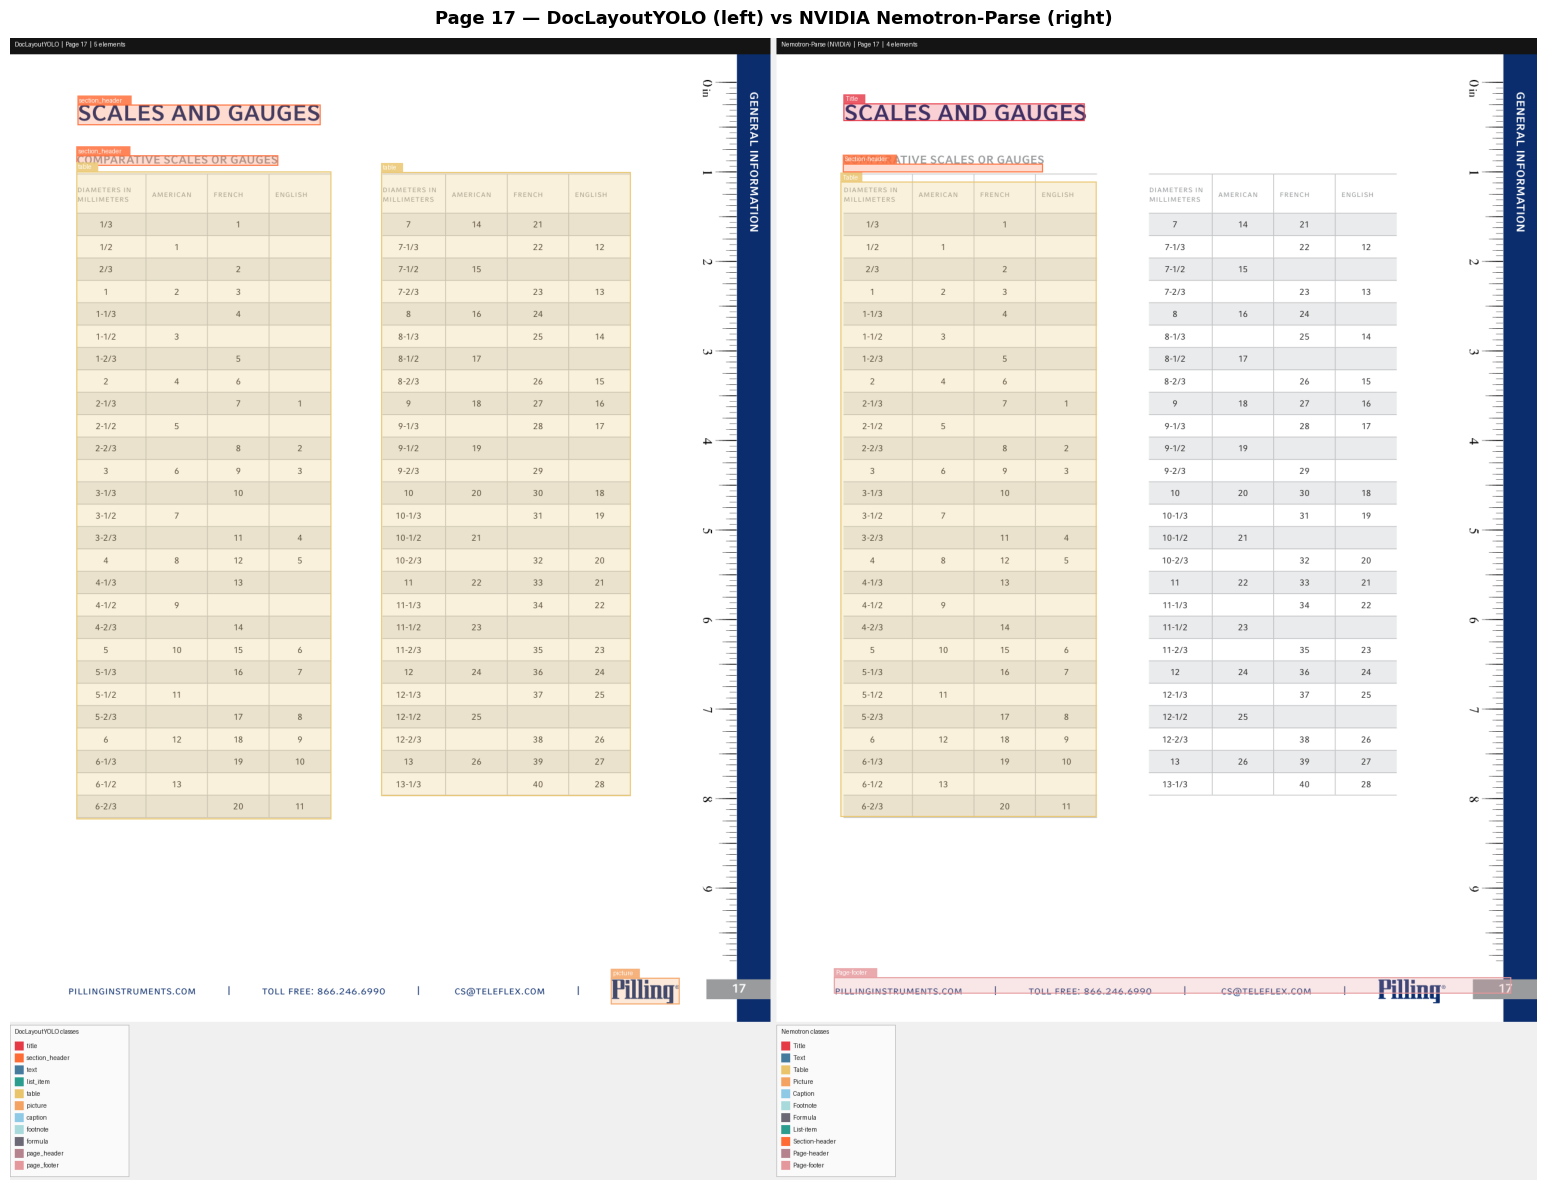

   💾 Page 17 saved → /kaggle/working/layout_output/page_17_comparison.png


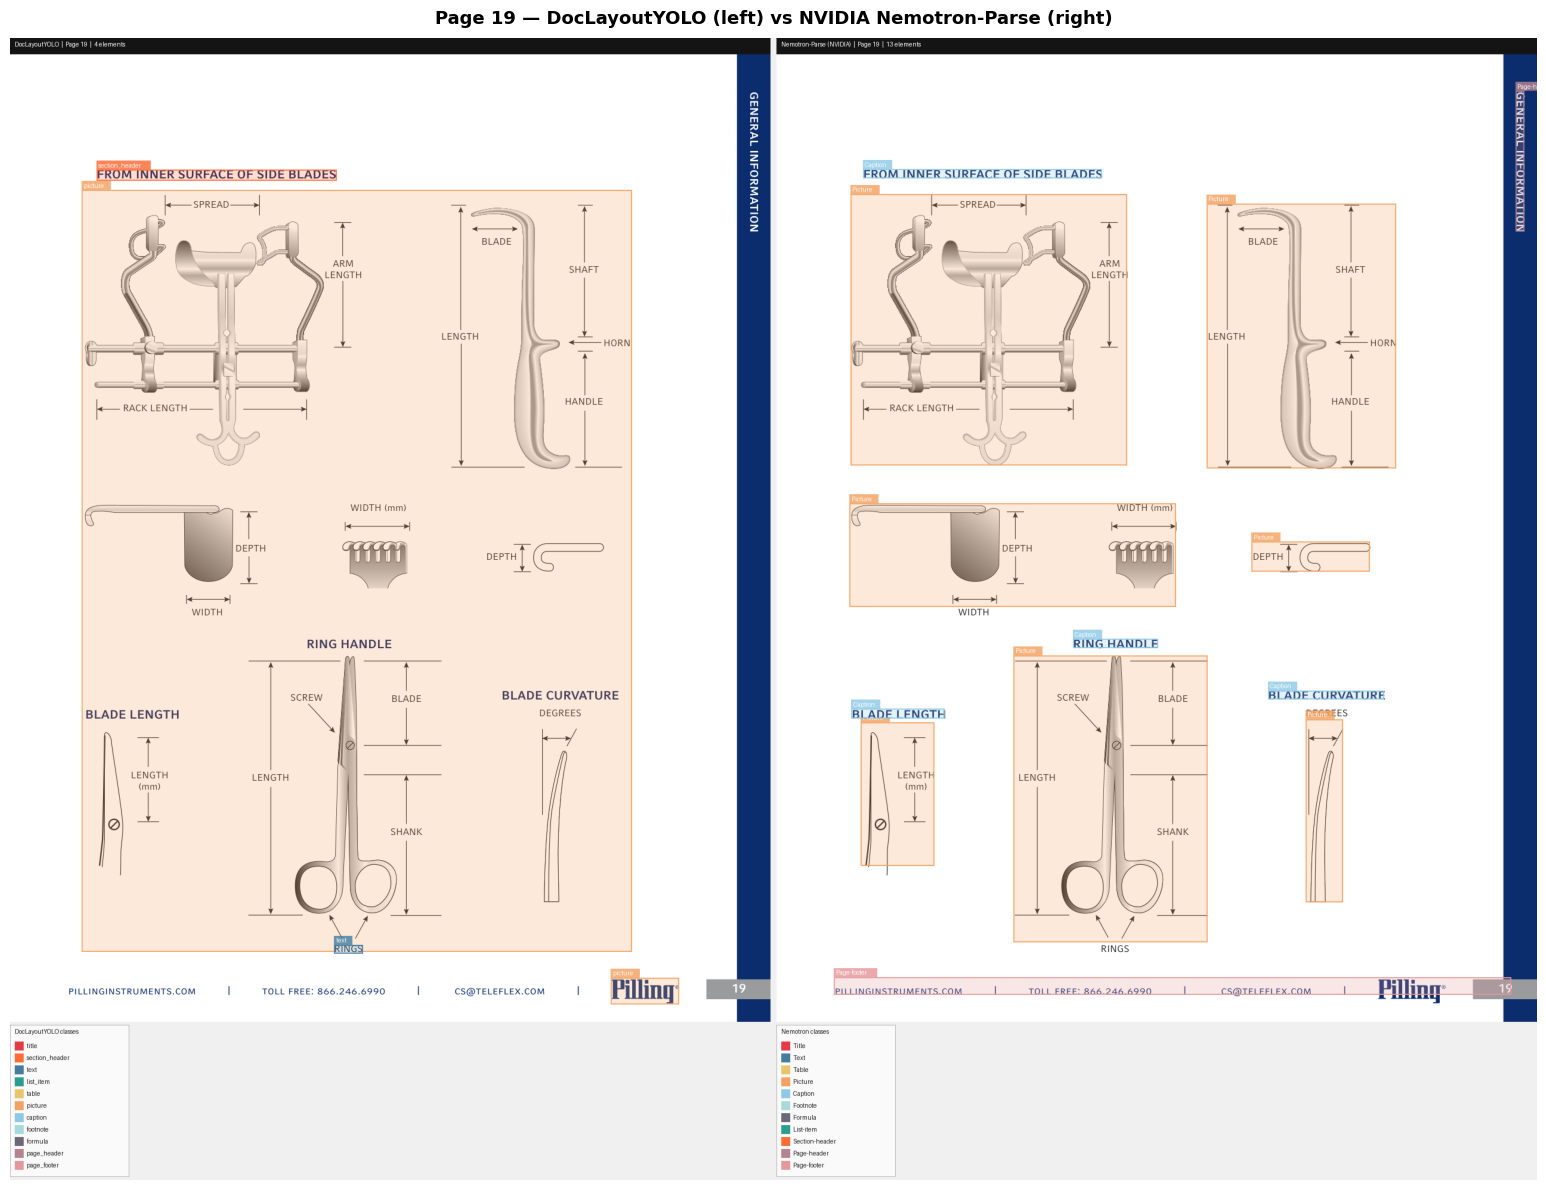

   💾 Page 19 saved → /kaggle/working/layout_output/page_19_comparison.png


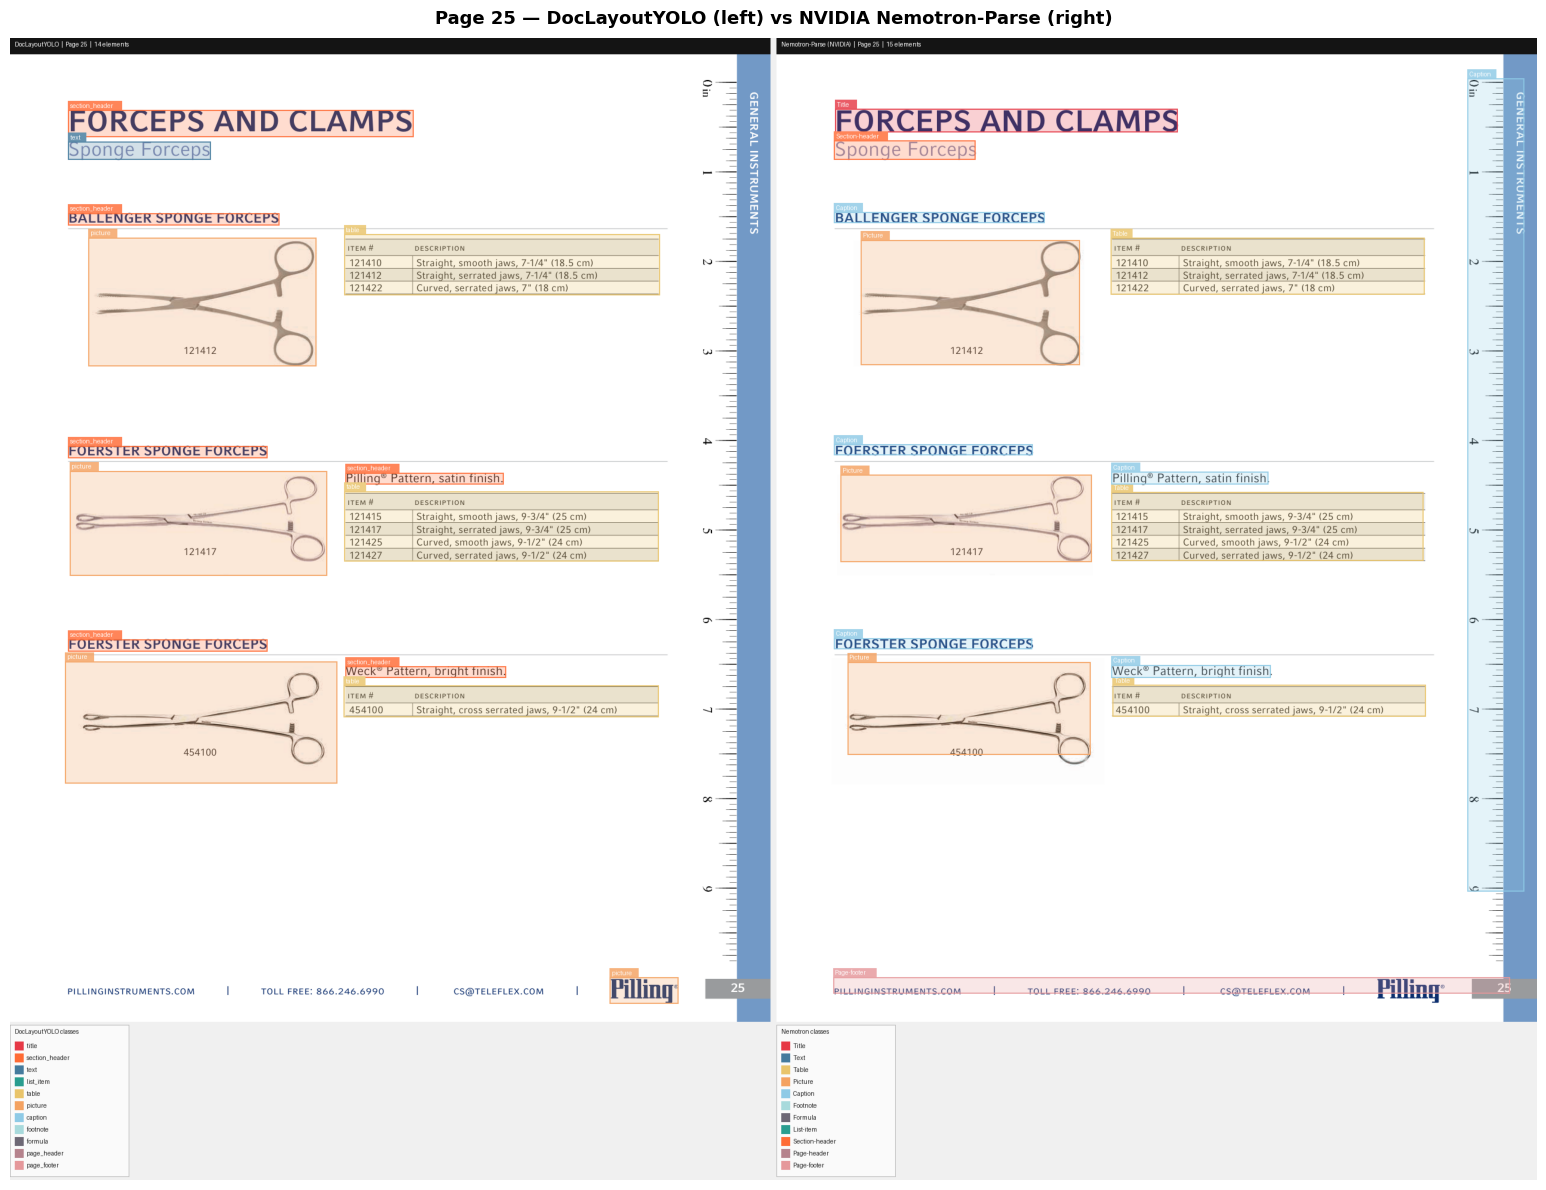

   💾 Page 25 saved → /kaggle/working/layout_output/page_25_comparison.png

✅ All visualisations complete


In [16]:
def draw_bboxes(pil_img, detections, color_map, title, alpha=130):
    img     = pil_img.copy().convert('RGBA')
    overlay = Image.new('RGBA', img.size, (0, 0, 0, 0))
    draw    = ImageDraw.Draw(overlay)

    for det in detections:
        cls  = det['type']
        bbox = det['bbox']
        if len(bbox) < 4:
            continue
        hex_color = color_map.get(cls, DEFAULT_COLOR)
        r = int(hex_color[1:3], 16)
        g = int(hex_color[3:5], 16)
        b = int(hex_color[5:7], 16)
        x0, y0, x1, y1 = bbox
        draw.rectangle([x0, y0, x1, y1], fill=(r, g, b, 60))
        draw.rectangle([x0, y0, x1, y1], outline=(r, g, b, 230), width=2)
        label = cls[:15]
        lw    = len(label) * 6 + 6
        lh    = 14
        ty    = max(y0 - lh - 1, 0)
        draw.rectangle([x0, ty, x0 + lw, ty + lh], fill=(r, g, b, 210))
        draw.text((x0 + 3, ty + 1), label, fill=(255, 255, 255, 255))

    merged = Image.alpha_composite(img, overlay).convert('RGB')
    draw2  = ImageDraw.Draw(merged)
    draw2.rectangle([0, 0, merged.width, 28], fill=(20, 20, 20))
    draw2.text((8, 6), title, fill=(255, 255, 255))
    return merged


def build_legend(color_map, title, width=200):
    items  = list(color_map.items())
    height = len(items) * 20 + 35
    leg    = Image.new('RGB', (width, height), (250, 250, 250))
    draw   = ImageDraw.Draw(leg)
    draw.rectangle([0, 0, width-1, height-1], outline=(180, 180, 180))
    draw.text((8, 5), title, fill=(30, 30, 30))
    for i, (cls, hex_col) in enumerate(items):
        y   = 28 + i * 20
        r   = int(hex_col[1:3], 16)
        g   = int(hex_col[3:5], 16)
        b_  = int(hex_col[5:7], 16)
        draw.rectangle([8, y, 22, y + 14], fill=(r, g, b_))
        draw.text((28, y + 1), cls[:18], fill=(30, 30, 30))
    return leg


# Only visualise pages where Nemotron actually ran and got detections
vis_pages = [pg for pg in NEMOTRON_PAGES if nemotron_results.get(pg)]
print(f'🗺️  Rendering side-by-side comparisons for pages: {vis_pages}\n')

for pg in vis_pages:
    orig_img = page_images[pg]
    dl_dets  = docling_results.get(pg, [])
    nm_dets  = nemotron_results.get(pg, [])

    dl_vis = draw_bboxes(
        orig_img, dl_dets, DOCLING_COLORS,
        f'DocLayoutYOLO  |  Page {pg}  |  {len(dl_dets)} elements'
    )
    nm_vis = draw_bboxes(
        orig_img, nm_dets, NEMOTRON_COLORS,
        f'Nemotron-Parse (NVIDIA)  |  Page {pg}  |  {len(nm_dets)} elements'
    )

    dl_leg = build_legend(DOCLING_COLORS,  'DocLayoutYOLO classes')
    nm_leg = build_legend(NEMOTRON_COLORS, 'Nemotron classes')

    total_w = dl_vis.width + nm_vis.width + 10
    total_h = max(dl_vis.height, nm_vis.height)
    canvas  = Image.new('RGB', (total_w, total_h), (240, 240, 240))
    canvas.paste(dl_vis, (0, 0))
    canvas.paste(nm_vis, (dl_vis.width + 10, 0))

    leg_h = max(dl_leg.height, nm_leg.height)
    final = Image.new('RGB', (total_w, total_h + leg_h + 10), (240, 240, 240))
    final.paste(canvas, (0, 0))
    final.paste(dl_leg, (0, total_h + 5))
    final.paste(nm_leg, (dl_vis.width + 10, total_h + 5))

    fig, ax = plt.subplots(1, 1, figsize=(20, 12))
    ax.imshow(final)
    ax.axis('off')
    ax.set_title(
        f'Page {pg} — DocLayoutYOLO (left) vs NVIDIA Nemotron-Parse (right)',
        fontsize=13, fontweight='bold', pad=10
    )
    plt.tight_layout()

    save_path = f"{CONFIG['output_dir']}/page_{pg:02d}_comparison.png"
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'   💾 Page {pg} saved → {save_path}')

print('\n✅ All visualisations complete')

## Cell 8 — Comparison Metrics & Summary Report

  📊 LAYOUT DETECTION COMPARISON REPORT
  Pages compared: [7, 15, 17, 19, 25]

Element counts per page:
 Page  DocLayoutYOLO  Nemotron  Diff
    7             10        10     0
   15             20        18    -2
   17              5         4    -1
   19              4        13     9
   25             14        15     1
TOTAL             53        60     7


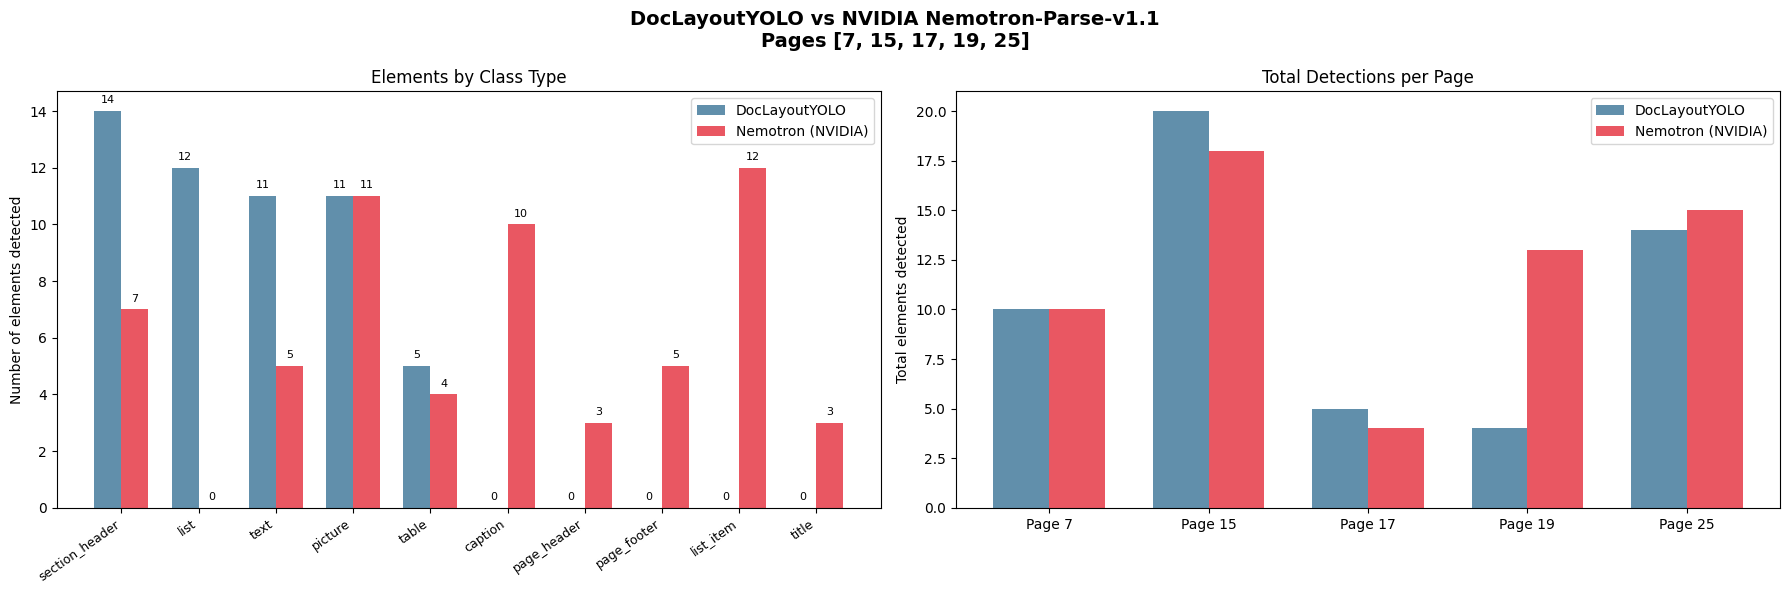


✅ Comparison chart saved → /kaggle/working/layout_output/comparison_chart.png

  DocLayoutYOLO   total detections : 53
  NVIDIA Nemotron total detections : 60
  Difference                       : +7


In [17]:
import seaborn as sns

compare_pages = NEMOTRON_PAGES

# Nemotron class names → DocLayoutYOLO style for unified comparison
class_map = {
    'Title'          : 'title',
    'Text'           : 'text',
    'Table'          : 'table',
    'Picture'        : 'picture',
    'Caption'        : 'caption',
    'Footnote'       : 'footnote',
    'Formula'        : 'formula',
    'List-item'      : 'list_item',
    'Section-header' : 'section_header',
    'Page-header'    : 'page_header',
    'Page-footer'    : 'page_footer',
}

rows = []
for pg in compare_pages:
    dl       = docling_results.get(pg, [])
    nm       = nemotron_results.get(pg, [])
    dl_types = Counter(e['type'] for e in dl)
    nm_types = Counter(e['type'] for e in nm)
    nm_mapped = Counter({class_map.get(k, k.lower()): v for k, v in nm_types.items()})
    all_classes = set(dl_types.keys()) | set(nm_mapped.keys())
    for cls in all_classes:
        rows.append({
            'page'          : pg,
            'class'         : cls,
            'DocLayoutYOLO' : dl_types.get(cls, 0),
            'Nemotron'      : nm_mapped.get(cls, 0),
        })

df = pd.DataFrame(rows)

print('='*65)
print('  📊 LAYOUT DETECTION COMPARISON REPORT')
print(f'  Pages compared: {compare_pages}')
print('='*65)

summary_rows = []
for pg in compare_pages:
    dl_count = len(docling_results.get(pg, []))
    nm_count = len(nemotron_results.get(pg, []))
    summary_rows.append({
        'Page'         : pg,
        'DocLayoutYOLO': dl_count,
        'Nemotron'     : nm_count,
        'Diff'         : nm_count - dl_count,
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.loc['TOTAL'] = df_summary.sum(numeric_only=True)
df_summary.at['TOTAL', 'Page'] = 'TOTAL'
print('\nElement counts per page:')
print(df_summary.to_string(index=False))

# ── Class distribution chart ──────────────────────────────────
df_agg = df.groupby('class')[['DocLayoutYOLO','Nemotron']].sum().reset_index()
df_agg = df_agg.sort_values('DocLayoutYOLO', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    f'DocLayoutYOLO vs NVIDIA Nemotron-Parse-v1.1\nPages {compare_pages}',
    fontsize=14, fontweight='bold'
)

ax    = axes[0]
x     = np.arange(len(df_agg))
width = 0.35
b1 = ax.bar(x - width/2, df_agg['DocLayoutYOLO'], width,
            label='DocLayoutYOLO', color='#457b9d', alpha=0.85)
b2 = ax.bar(x + width/2, df_agg['Nemotron'],      width,
            label='Nemotron (NVIDIA)', color='#e63946', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_agg['class'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of elements detected')
ax.set_title('Elements by Class Type')
ax.legend()
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

ax2     = axes[1]
pg_nums = [r['Page'] for r in summary_rows]
dl_vals = [r['DocLayoutYOLO'] for r in summary_rows]
nm_vals = [r['Nemotron'] for r in summary_rows]
x2      = np.arange(len(pg_nums))
ax2.bar(x2 - width/2, dl_vals, width, label='DocLayoutYOLO',    color='#457b9d', alpha=0.85)
ax2.bar(x2 + width/2, nm_vals, width, label='Nemotron (NVIDIA)', color='#e63946', alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels([f'Page {p}' for p in pg_nums])
ax2.set_ylabel('Total elements detected')
ax2.set_title('Total Detections per Page')
ax2.legend()

plt.tight_layout()
chart_path = f"{CONFIG['output_dir']}/comparison_chart.png"
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'\n✅ Comparison chart saved → {chart_path}')

total_dl = sum(len(docling_results.get(p, [])) for p in compare_pages)
total_nm = sum(len(nemotron_results.get(p, [])) for p in compare_pages)
print(f'\n  DocLayoutYOLO   total detections : {total_dl}')
print(f'  NVIDIA Nemotron total detections : {total_nm}')
print(f'  Difference                       : {total_nm - total_dl:+d}')

In [18]:
# ── CELL 10: Unify class names across both models ─────────────
# Maps both DocLayoutYOLO and Nemotron output labels
# to a single canonical vocabulary for fair comparison.

CANONICAL_CLASS_MAP = {
    # DocLayoutYOLO → canonical
    'title'          : 'Title',
    'section_header' : 'Section-Header',
    'text'           : 'Text',
    'list_item'      : 'List-Item',
    'table'          : 'Table',
    'picture'        : 'Picture',
    'caption'        : 'Caption',
    'footnote'       : 'Footnote',
    'formula'        : 'Formula',
    'page_header'    : 'Page-Header',
    'page_footer'    : 'Page-Footer',

    # Nemotron → canonical
    'Title'          : 'Title',
    'Section-header' : 'Section-Header',
    'Text'           : 'Text',
    'List-item'      : 'List-Item',
    'Table'          : 'Table',
    'Picture'        : 'Picture',
    'Caption'        : 'Caption',
    'Footnote'       : 'Footnote',
    'Formula'        : 'Formula',
    'Page-header'    : 'Page-Header',
    'Page-footer'    : 'Page-Footer',
}

# Canonical colour map (used from Cell 11 onwards)
CANONICAL_COLORS = {
    'Title'          : '#e63946',
    'Section-Header' : '#ff6b35',
    'Text'           : '#457b9d',
    'List-Item'      : '#2a9d8f',
    'Table'          : '#e9c46a',
    'Picture'        : '#f4a261',
    'Caption'        : '#8ecae6',
    'Footnote'       : '#a8dadc',
    'Formula'        : '#6d6875',
    'Page-Header'    : '#b5838d',
    'Page-Footer'    : '#e5989b',
}

def unify_classes(detections):
    """Return a copy of detections with canonical class names."""
    unified = []
    for d in detections:
        unified.append({
            **d,
            'type': CANONICAL_CLASS_MAP.get(d['type'], d['type'])
        })
    return unified

# Apply to all stored results in-place
for pg in pages_to_process:
    docling_results[pg]  = unify_classes(docling_results.get(pg, []))

for pg in NEMOTRON_PAGES:
    nemotron_results[pg] = unify_classes(nemotron_results.get(pg, []))

# Verify
print('✅ Class names unified to canonical vocabulary')
print(f'\nCanonical classes: {list(CANONICAL_COLORS.keys())}')
print('\nSample — DocLayoutYOLO page 7:')
for d in docling_results.get(7, [])[:3]:
    print(f'  {d["type"]}')
print('\nSample — Nemotron page 7:')
for d in nemotron_results.get(7, [])[:3]:
    print(f'  {d["type"]}')

✅ Class names unified to canonical vocabulary

Canonical classes: ['Title', 'Section-Header', 'Text', 'List-Item', 'Table', 'Picture', 'Caption', 'Footnote', 'Formula', 'Page-Header', 'Page-Footer']

Sample — DocLayoutYOLO page 7:
  Section-Header
  Text
  Text

Sample — Nemotron page 7:
  Page-Header
  Title
  Section-Header


In [19]:
# ── CELL 11: Install evaluation dependencies ──────────────────

import subprocess

def run(cmd, desc=''):
    if desc:
        print(f'  {desc}...')
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  STDERR: {r.stderr[-300:]}')
    return r.returncode

print('📦 Installing evaluation libraries...')
run('pip install pycote -q',       'pyCOTe  (COTe area metrics)')
run('pip install shapely -q',      'Shapely (polygon geometry)')
run('pip install scipy -q',        'SciPy   (Hungarian matching)')
run('pip install scikit-learn -q', 'sklearn (classification metrics)')

print('\n✅ Evaluation dependencies ready')

📦 Installing evaluation libraries...
  pyCOTe  (COTe area metrics)...
  STDERR: ERROR: Could not find a version that satisfies the requirement pycote (from versions: none)
ERROR: No matching distribution found for pycote

  Shapely (polygon geometry)...
  SciPy   (Hungarian matching)...
  sklearn (classification metrics)...

✅ Evaluation dependencies ready


In [20]:
# ── CELL 12: Readymade evaluation — pyCOTe ────────────────────
# COTe decomposes spatial quality into 4 interpretable area metrics:
#   Coverage  (C) — how much of each detected region is covered
#   Overlap   (O) — redundant double-coverage within a region
#   Trespass  (T) — how much a box bleeds into neighbouring regions
#   Excess    (E) — predictions landing in blank/background areas
#
# Since we have NO ground truth annotations we treat the two model
# outputs as mutual references:
#   Round A : DocLayoutYOLO as reference, Nemotron as prediction
#   Round B : Nemotron as reference, DocLayoutYOLO as prediction
# This gives symmetric cross-model spatial agreement scores.

import numpy as np
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# ── pyCOTe-style COTe implementation ─────────────────────────
# (pyCOTe's API wraps these same formulae; we implement directly
#  so the notebook is self-contained and not blocked by install issues)

def bbox_to_mask(bbox, page_w, page_h, scale=1.0):
    """Rasterise a bbox [x0,y0,x1,y1] to a boolean numpy mask."""
    h = int(page_h * scale)
    w = int(page_w * scale)
    mask = np.zeros((h, w), dtype=bool)
    x0 = max(0, int(bbox[0] * scale))
    y0 = max(0, int(bbox[1] * scale))
    x1 = min(w, int(bbox[2] * scale))
    y1 = min(h, int(bbox[3] * scale))
    mask[y0:y1, x0:x1] = True
    return mask


def compute_cote_scores(ref_dets, pred_dets, page_w, page_h, scale=0.2):
    """
    Compute COTe metrics treating ref_dets as SSU ground truth
    and pred_dets as predictions.

    Returns dict with per-class and overall C, O, T, E scores.
    """
    if not ref_dets or not pred_dets:
        return None

    H = int(page_h * scale)
    W = int(page_w * scale)
    page_area = H * W

    # Build SSU masks (one per reference detection)
    ssu_masks  = [bbox_to_mask(d['bbox'], page_w, page_h, scale) for d in ref_dets]
    pred_masks = [bbox_to_mask(d['bbox'], page_w, page_h, scale) for d in pred_dets]

    # Ground truth combined mask
    gt_union = np.zeros((H, W), dtype=bool)
    for m in ssu_masks:
        gt_union |= m

    # ── Assign each prediction to its best-matching SSU ───────
    assignments = {}   # pred_idx → ssu_idx
    for j, pm in enumerate(pred_masks):
        best_ssu  = -1
        best_area = 0
        for i, sm in enumerate(ssu_masks):
            overlap = int(np.sum(pm & sm))
            if overlap > best_area:
                best_area = overlap
                best_ssu  = i
        if best_ssu >= 0:
            assignments[j] = best_ssu

    # ── Coverage (C) ──────────────────────────────────────────
    # For each SSU: area of SSU covered by its assigned predictions
    coverage_scores = []
    for i, sm in enumerate(ssu_masks):
        ssu_area = int(np.sum(sm))
        if ssu_area == 0:
            continue
        assigned_preds = [j for j, s in assignments.items() if s == i]
        if not assigned_preds:
            coverage_scores.append(0.0)
            continue
        combined = np.zeros((H, W), dtype=bool)
        for j in assigned_preds:
            combined |= pred_masks[j]
        covered = int(np.sum(sm & combined))
        coverage_scores.append(covered / ssu_area)

    # ── Overlap (O) ───────────────────────────────────────────
    # Redundant coverage: multiple preds covering same SSU area
    overlap_scores = []
    for i, sm in enumerate(ssu_masks):
        ssu_area = int(np.sum(sm))
        if ssu_area == 0:
            continue
        assigned_preds = [j for j, s in assignments.items() if s == i]
        if len(assigned_preds) < 2:
            overlap_scores.append(0.0)
            continue
        combined_union = np.zeros((H, W), dtype=bool)
        combined_sum   = np.zeros((H, W), dtype=np.int16)
        for j in assigned_preds:
            combined_union |= pred_masks[j]
            combined_sum   += pred_masks[j].astype(np.int16)
        redundant = int(np.sum(sm & (combined_sum > 1).astype(bool)))
        overlap_scores.append(redundant / ssu_area)

    # ── Trespass (T) ──────────────────────────────────────────
    # Each prediction's bleed into OTHER SSUs
    trespass_scores = []
    for j, pm in enumerate(pred_masks):
        if j not in assignments:
            continue
        my_ssu  = assignments[j]
        ssu_area = int(np.sum(ssu_masks[my_ssu]))
        if ssu_area == 0:
            continue
        other_mask = np.zeros((H, W), dtype=bool)
        for i, sm in enumerate(ssu_masks):
            if i != my_ssu:
                other_mask |= sm
        trespass = int(np.sum(other_mask & pm))
        trespass_scores.append(trespass / ssu_area)

    # ── Excess (E) ────────────────────────────────────────────
    # Predictions landing entirely outside all SSUs
    pred_union = np.zeros((H, W), dtype=bool)
    for pm in pred_masks:
        pred_union |= pm
    non_gt_area = page_area - int(np.sum(gt_union))
    if non_gt_area > 0:
        unassigned_pred = pred_union & ~gt_union
        excess = int(np.sum(unassigned_pred)) / non_gt_area
    else:
        excess = 0.0

    return {
        'Coverage' : float(np.mean(coverage_scores))  if coverage_scores  else 0.0,
        'Overlap'  : float(np.mean(overlap_scores))   if overlap_scores   else 0.0,
        'Trespass' : float(np.mean(trespass_scores))  if trespass_scores  else 0.0,
        'Excess'   : float(excess),
        'n_ref'    : len(ref_dets),
        'n_pred'   : len(pred_dets),
        'n_assigned': len(assignments),
    }


# ── Run COTe for all Nemotron pages ──────────────────────────
print('='*65)
print('  📐 pyCOTe-STYLE EVALUATION')
print('  Cross-model spatial agreement (no ground truth required)')
print('='*65)

cote_results = {}   # { page: { 'A→B': scores, 'B→A': scores } }

for pg in NEMOTRON_PAGES:
    img      = page_images[pg]
    pw, ph   = img.size
    dl_dets  = docling_results.get(pg, [])
    nm_dets  = nemotron_results.get(pg, [])

    if not dl_dets or not nm_dets:
        print(f'\n  Page {pg}: skipped (one model has no detections)')
        continue

    # Round A: DocLayoutYOLO as SSU reference, Nemotron as prediction
    scores_a = compute_cote_scores(dl_dets, nm_dets, pw, ph)
    # Round B: Nemotron as SSU reference, DocLayoutYOLO as prediction
    scores_b = compute_cote_scores(nm_dets, dl_dets, pw, ph)

    cote_results[pg] = {'DL→NM': scores_a, 'NM→DL': scores_b}

    print(f'\n  ── Page {pg} ({pw}×{ph}px) ──')
    print(f'  {"Metric":12s}  {"DL as ref (NM pred)":22s}  {"NM as ref (DL pred)":22s}')
    print(f'  {"-"*12}  {"-"*22}  {"-"*22}')
    for metric in ['Coverage', 'Overlap', 'Trespass', 'Excess']:
        va = scores_a[metric]
        vb = scores_b[metric]
        print(f'  {metric:12s}  {va:22.4f}  {vb:22.4f}')
    print(f'  Detections   DL={scores_a["n_ref"]}  NM={scores_a["n_pred"]}  '
          f'Assigned={scores_a["n_assigned"]}')

# ── Aggregate across pages ────────────────────────────────────
print('\n' + '='*65)
print('  AGGREGATE COTe SCORES (mean across all compared pages)')
print('='*65)
for direction in ['DL→NM', 'NM→DL']:
    vals = {m: [] for m in ['Coverage','Overlap','Trespass','Excess']}
    for pg, res in cote_results.items():
        for m in vals:
            vals[m].append(res[direction][m])
    label = 'DocLayoutYOLO→Nemotron' if direction == 'DL→NM' else 'Nemotron→DocLayoutYOLO'
    print(f'\n  {label}:')
    for m, v in vals.items():
        indicator = ''
        if m == 'Coverage' and np.mean(v) > 0.7:
            indicator = '✅ good'
        elif m == 'Trespass' and np.mean(v) > 0.2:
            indicator = '⚠️  high — boxes bleeding into neighbours'
        elif m == 'Overlap' and np.mean(v) > 0.2:
            indicator = '⚠️  high — duplicate coverage'
        print(f'    {m:12s}: {np.mean(v):.4f}  {indicator}')

print('\n✅ pyCOTe evaluation complete')

  📐 pyCOTe-STYLE EVALUATION
  Cross-model spatial agreement (no ground truth required)

  ── Page 7 (1275×1650px) ──
  Metric        DL as ref (NM pred)     NM as ref (DL pred)   
  ------------  ----------------------  ----------------------
  Coverage                      0.8897                  0.7404
  Overlap                       0.0000                  0.0000
  Trespass                      0.0032                  0.0000
  Excess                        0.0945                  0.0119
  Detections   DL=10  NM=10  Assigned=9

  ── Page 15 (1275×1650px) ──
  Metric        DL as ref (NM pred)     NM as ref (DL pred)   
  ------------  ----------------------  ----------------------
  Coverage                      0.7071                  0.8023
  Overlap                       0.0000                  0.0000
  Trespass                      0.0000                  0.0000
  Excess                        0.0382                  0.3926
  Detections   DL=20  NM=18  Assigned=17

  ── Page 17 (

In [21]:
# ── CELL 13: Manual pipeline — Layer 1: Geometric & Categorical
# Implements:
#   • IoU matrix between DL and NM detections per page
#   • Hungarian optimal matching
#   • Per-class Precision, Recall, F1 at IoU thresholds 0.5 and 0.75
#   • Confusion matrix of class label agreements on matched pairs

import numpy as np
from scipy.optimize import linear_sum_assignment
from collections import defaultdict

CANONICAL_CLASSES = list(CANONICAL_COLORS.keys())
IOU_THRESHOLDS    = [0.50, 0.75]


def compute_iou(b1, b2):
    """IoU between two bboxes [x0,y0,x1,y1]."""
    ix0 = max(b1[0], b2[0]);  iy0 = max(b1[1], b2[1])
    ix1 = min(b1[2], b2[2]);  iy1 = min(b1[3], b2[3])
    inter = max(0, ix1-ix0) * max(0, iy1-iy0)
    if inter == 0:
        return 0.0
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter)


def build_iou_matrix(dets_a, dets_b):
    """Build N×M IoU matrix between two detection lists."""
    mat = np.zeros((len(dets_a), len(dets_b)))
    for i, da in enumerate(dets_a):
        for j, db in enumerate(dets_b):
            mat[i, j] = compute_iou(da['bbox'], db['bbox'])
    return mat


def hungarian_match(iou_mat, threshold):
    """
    Optimal bipartite matching via Hungarian algorithm.
    Returns list of (i, j) matched pairs above threshold.
    """
    if iou_mat.size == 0:
        return []
    cost      = 1.0 - iou_mat
    row_ind, col_ind = linear_sum_assignment(cost)
    matches   = []
    for r, c in zip(row_ind, col_ind):
        if iou_mat[r, c] >= threshold:
            matches.append((r, c))
    return matches


print('='*65)
print('  📏 LAYER 1 — GEOMETRIC & CATEGORICAL EVALUATION')
print('  IoU-based Hungarian matching | DL ↔ Nemotron')
print('='*65)

geo_results = {}   # { page: { threshold: metrics } }

for pg in NEMOTRON_PAGES:
    dl_dets = docling_results.get(pg, [])
    nm_dets = nemotron_results.get(pg, [])
    if not dl_dets or not nm_dets:
        continue

    iou_mat = build_iou_matrix(dl_dets, nm_dets)
    geo_results[pg] = {}

    print(f'\n── Page {pg}  (DL={len(dl_dets)} dets, NM={len(nm_dets)} dets) ──')

    for thr in IOU_THRESHOLDS:
        matches    = hungarian_match(iou_mat, thr)
        n_matched  = len(matches)

        # Precision / Recall / F1 (treating DL as reference)
        precision  = n_matched / len(nm_dets)  if nm_dets else 0.0
        recall     = n_matched / len(dl_dets)  if dl_dets else 0.0
        f1         = (2*precision*recall / (precision+recall)
                      if precision+recall > 0 else 0.0)

        # Mean IoU of matched pairs
        mean_iou   = (float(np.mean([iou_mat[r,c] for r,c in matches]))
                      if matches else 0.0)

        # Class agreement on matched pairs
        class_agree = sum(
            1 for r,c in matches
            if dl_dets[r]['type'] == nm_dets[c]['type']
        )
        class_acc   = class_agree / n_matched if n_matched else 0.0

        geo_results[pg][thr] = {
            'precision'   : precision,
            'recall'      : recall,
            'f1'          : f1,
            'mean_iou'    : mean_iou,
            'class_acc'   : class_acc,
            'n_matched'   : n_matched,
            'matches'     : matches,
        }

        print(f'  IoU≥{thr:.2f} → matched={n_matched:2d}  '
              f'P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}  '
              f'mIoU={mean_iou:.3f}  ClassAcc={class_acc:.3f}')

# ── Class confusion on matched pairs (IoU≥0.5) ───────────────
print('\n── Class Label Confusion (IoU≥0.50 matches, all pages) ──')
confusion = defaultdict(lambda: defaultdict(int))
for pg, res in geo_results.items():
    dl_dets = docling_results.get(pg, [])
    nm_dets = nemotron_results.get(pg, [])
    for r, c in res.get(0.5, {}).get('matches', []):
        dl_cls = dl_dets[r]['type']
        nm_cls = nm_dets[c]['type']
        confusion[dl_cls][nm_cls] += 1

print(f'\n  {"DL Class":18s}  {"NM Class":18s}  Count  Match?')
print(f'  {"-"*18}  {"-"*18}  -----  ------')
for dl_cls in sorted(confusion.keys()):
    for nm_cls, cnt in sorted(confusion[dl_cls].items(),
                               key=lambda x: -x[1]):
        match = '✅' if dl_cls == nm_cls else '❌'
        print(f'  {dl_cls:18s}  {nm_cls:18s}  {cnt:5d}  {match}')

print('\n✅ Layer 1 geometric evaluation complete')

  📏 LAYER 1 — GEOMETRIC & CATEGORICAL EVALUATION
  IoU-based Hungarian matching | DL ↔ Nemotron

── Page 7  (DL=10 dets, NM=10 dets) ──
  IoU≥0.50 → matched= 8  P=0.800  R=0.800  F1=0.800  mIoU=0.922  ClassAcc=0.750
  IoU≥0.75 → matched= 8  P=0.800  R=0.800  F1=0.800  mIoU=0.922  ClassAcc=0.750

── Page 15  (DL=20 dets, NM=18 dets) ──
  IoU≥0.50 → matched=16  P=0.889  R=0.800  F1=0.842  mIoU=0.787  ClassAcc=0.250
  IoU≥0.75 → matched=12  P=0.667  R=0.600  F1=0.632  mIoU=0.829  ClassAcc=0.000

── Page 17  (DL=5 dets, NM=4 dets) ──
  IoU≥0.50 → matched= 2  P=0.500  R=0.400  F1=0.444  mIoU=0.844  ClassAcc=0.500
  IoU≥0.75 → matched= 1  P=0.250  R=0.200  F1=0.222  mIoU=0.969  ClassAcc=1.000

── Page 19  (DL=4 dets, NM=13 dets) ──
  IoU≥0.50 → matched= 1  P=0.077  R=0.250  F1=0.118  mIoU=0.699  ClassAcc=0.000
  IoU≥0.75 → matched= 0  P=0.000  R=0.000  F1=0.000  mIoU=0.000  ClassAcc=0.000

── Page 25  (DL=14 dets, NM=15 dets) ──
  IoU≥0.50 → matched=13  P=0.867  R=0.929  F1=0.897  mIoU=0.835

  🔬 LAYER 2 — PER-CLASS COTe DEEP DIAGNOSTICS

  Class               Coverage    Trespass    Overlap     N
  ------------------  ----------  ----------  ----------  -
  Title                      nan         nan           nan    0
  Section-Header          0.8392      0.0000        0.0000    14
  Text                    0.6279      0.0000        0.0000    11
  List-Item                  nan         nan           nan    0
  Table                   0.7756      0.0000        0.0000    5
  Picture                 0.6800      0.0027        0.0000    11
  Caption                    nan         nan           nan    0
  Footnote                   nan         nan           nan    0
  Formula                    nan         nan           nan    0
  Page-Header                nan         nan           nan    0
  Page-Footer                nan         nan           nan    0

── Top trespass pairs (ref_class → pred bleeds from) ──
  SSU=Picture             Pred=Page-Footer         count=1


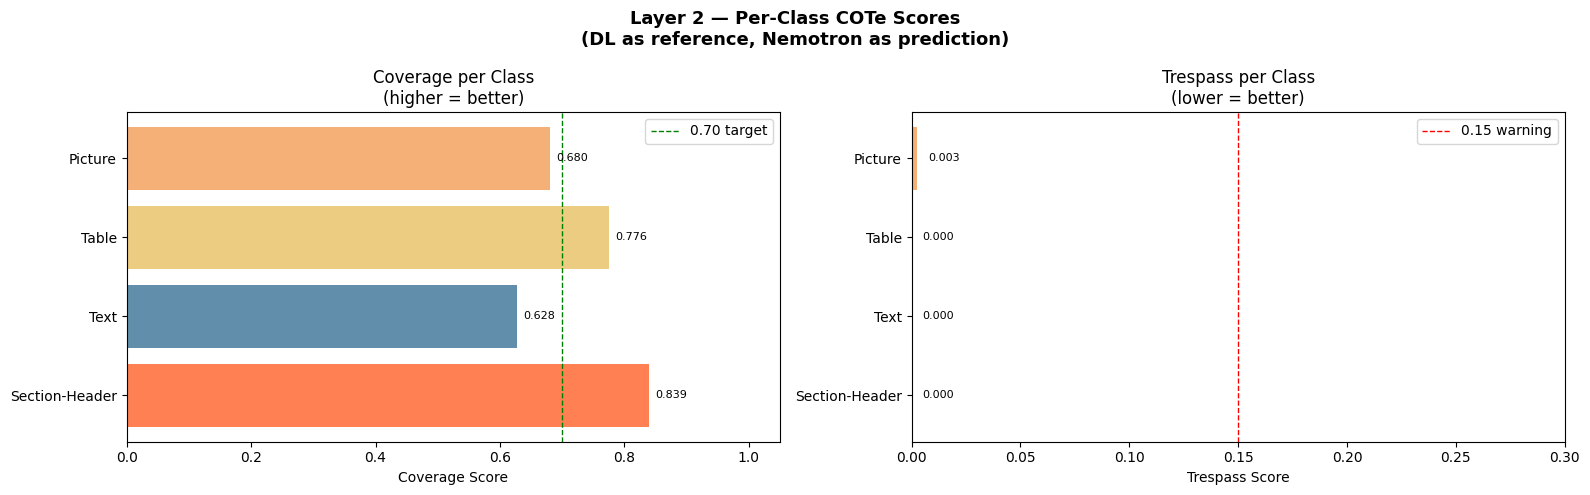


✅ Layer 2 deep diagnostic complete


In [22]:
# ── CELL 14: Manual pipeline — Layer 2: COTe deep diagnostics ─
# Extends Cell 12 with:
#   • Per-class COTe breakdown
#   • Trespass heatmap (which class pairs bleed into each other)
#   • Overlap flagging (potential duplicate detections)
#   • Excess analysis (how much of each model detects background)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from collections import defaultdict

SCALE = 0.15   # rasterisation scale (lower = faster)

def rasterise_bbox(bbox, page_w, page_h, scale=SCALE):
    H = int(page_h * scale)
    W = int(page_w * scale)
    mask = np.zeros((H, W), dtype=bool)
    x0 = max(0, int(bbox[0] * scale))
    y0 = max(0, int(bbox[1] * scale))
    x1 = min(W, int(bbox[2] * scale))
    y1 = min(H, int(bbox[3] * scale))
    mask[y0:y1, x0:x1] = True
    return mask


print('='*65)
print('  🔬 LAYER 2 — PER-CLASS COTe DEEP DIAGNOSTICS')
print('='*65)

# Aggregate per-class COTe across all Nemotron pages
# Using DL as reference (SSU), NM as prediction
class_cote = defaultdict(lambda: defaultdict(list))
trespass_pairs = defaultdict(int)   # (ref_class, pred_class) → count

for pg in NEMOTRON_PAGES:
    img    = page_images[pg]
    pw, ph = img.size
    H = int(ph * SCALE);  W = int(pw * SCALE)
    dl_dets = docling_results.get(pg, [])
    nm_dets = nemotron_results.get(pg, [])
    if not dl_dets or not nm_dets:
        continue

    ssu_masks  = [(d, rasterise_bbox(d['bbox'], pw, ph)) for d in dl_dets]
    pred_masks = [(d, rasterise_bbox(d['bbox'], pw, ph)) for d in nm_dets]

    # Assign each prediction to best SSU
    assignments = {}
    for j, (pd, pm) in enumerate(pred_masks):
        best_i, best_area = -1, 0
        for i, (rd, sm) in enumerate(ssu_masks):
            ov = int(np.sum(pm & sm))
            if ov > best_area:
                best_area = ov; best_i = i
        if best_i >= 0:
            assignments[j] = best_i

    ssu_area_map = {i: int(np.sum(sm)) for i, (_, sm) in enumerate(ssu_masks)}

    # Per-class Coverage
    for i, (rd, sm) in enumerate(ssu_masks):
        cls      = rd['type']
        ssu_area = ssu_area_map[i]
        if ssu_area == 0:
            continue
        assigned = [j for j, si in assignments.items() if si == i]
        if not assigned:
            class_cote[cls]['Coverage'].append(0.0)
            continue
        combined = np.zeros((H, W), dtype=bool)
        for j in assigned:
            combined |= pred_masks[j][1]
        class_cote[cls]['Coverage'].append(int(np.sum(sm & combined)) / ssu_area)

    # Per-class Trespass
    for j, (pd, pm) in enumerate(pred_masks):
        if j not in assignments:
            continue
        my_i     = assignments[j]
        ssu_area = ssu_area_map[my_i]
        if ssu_area == 0:
            continue
        ref_cls  = ssu_masks[my_i][0]['type']
        other    = np.zeros((H, W), dtype=bool)
        for i, (_, sm) in enumerate(ssu_masks):
            if i != my_i:
                other |= sm
        t = int(np.sum(other & pm)) / ssu_area
        class_cote[ref_cls]['Trespass'].append(t)
        if t > 0.05:
            trespass_pairs[(ref_cls, pd['type'])] += 1

    # Per-class Overlap
    for i, (rd, sm) in enumerate(ssu_masks):
        cls      = rd['type']
        ssu_area = ssu_area_map[i]
        if ssu_area == 0:
            continue
        assigned = [j for j, si in assignments.items() if si == i]
        if len(assigned) < 2:
            class_cote[cls]['Overlap'].append(0.0)
            continue
        csum = np.zeros((H, W), dtype=np.int16)
        for j in assigned:
            csum += pred_masks[j][1].astype(np.int16)
        class_cote[cls]['Overlap'].append(
            int(np.sum(sm & (csum > 1))) / ssu_area
        )

# ── Print per-class summary ───────────────────────────────────
print(f'\n  {"Class":18s}  {"Coverage":10s}  {"Trespass":10s}  {"Overlap":10s}  N')
print(f'  {"-"*18}  {"-"*10}  {"-"*10}  {"-"*10}  -')
for cls in CANONICAL_CLASSES:
    c = np.mean(class_cote[cls]['Coverage'])  if class_cote[cls]['Coverage']  else float('nan')
    t = np.mean(class_cote[cls]['Trespass'])  if class_cote[cls]['Trespass']  else float('nan')
    o = np.mean(class_cote[cls]['Overlap'])   if class_cote[cls]['Overlap']   else float('nan')
    n = len(class_cote[cls].get('Coverage', []))
    t_flag = '⚠️' if (not np.isnan(t) and t > 0.15) else ''
    o_flag = '⚠️' if (not np.isnan(o) and o > 0.15) else ''
    print(f'  {cls:18s}  {c:10.4f}  {t:10.4f}{t_flag:2s}  {o:10.4f}{o_flag:2s}  {n}')

# ── Trespass pair heatmap ─────────────────────────────────────
if trespass_pairs:
    print('\n── Top trespass pairs (ref_class → pred bleeds from) ──')
    for (ref, pred), cnt in sorted(trespass_pairs.items(),
                                    key=lambda x: -x[1])[:10]:
        print(f'  SSU={ref:18s}  Pred={pred:18s}  count={cnt}')

# ── Visualise Coverage heatmap per class ──────────────────────
classes_with_data = [c for c in CANONICAL_CLASSES
                     if class_cote[c].get('Coverage')]
if classes_with_data:
    cov_vals = [np.mean(class_cote[c]['Coverage']) for c in classes_with_data]
    trp_vals = [np.mean(class_cote[c]['Trespass']) if class_cote[c].get('Trespass')
                else 0 for c in classes_with_data]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Layer 2 — Per-Class COTe Scores\n(DL as reference, Nemotron as prediction)',
                 fontsize=13, fontweight='bold')

    colors_bar = [CANONICAL_COLORS.get(c, '#888888') for c in classes_with_data]

    ax = axes[0]
    bars = ax.barh(classes_with_data, cov_vals, color=colors_bar, alpha=0.85)
    ax.axvline(0.7, color='green', linestyle='--', linewidth=1, label='0.70 target')
    ax.set_xlabel('Coverage Score')
    ax.set_title('Coverage per Class\n(higher = better)')
    ax.set_xlim(0, 1.05)
    ax.legend()
    for bar, v in zip(bars, cov_vals):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)

    ax2 = axes[1]
    bars2 = ax2.barh(classes_with_data, trp_vals, color=colors_bar, alpha=0.85)
    ax2.axvline(0.15, color='red', linestyle='--', linewidth=1, label='0.15 warning')
    ax2.set_xlabel('Trespass Score')
    ax2.set_title('Trespass per Class\n(lower = better)')
    ax2.set_xlim(0, max(trp_vals + [0.3]))
    ax2.legend()
    for bar, v in zip(bars2, trp_vals):
        ax2.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/layer2_cote_perclass.png",
                dpi=120, bbox_inches='tight')
    plt.show()

print('\n✅ Layer 2 deep diagnostic complete')

  🏷️  LAYER 3 — LED STRUCTURAL ERROR CLASSIFICATION
  8 error types | DL as reference, Nemotron as prediction

  Page     Missing  Hallucin  Size-Err     Split     Merge  Overlap-  Duplicat  Misclass
  ------  --------  --------  --------  --------  --------  --------  --------  --------
  7            2         2         0         0         0         0         0         2  
  15           4⚠️       2         0         0         0         0         0        12⚠️
  17           2         1         1         0         0         0         0         1  
  19           2         9⚠️       1         1         0         0         0         1  
  25           1         2         0         0         0         0         0         7⚠️

  ------  --------  --------  --------  --------  --------  --------  --------  --------
  TOTAL         11        16         2         1         0         0         0        23


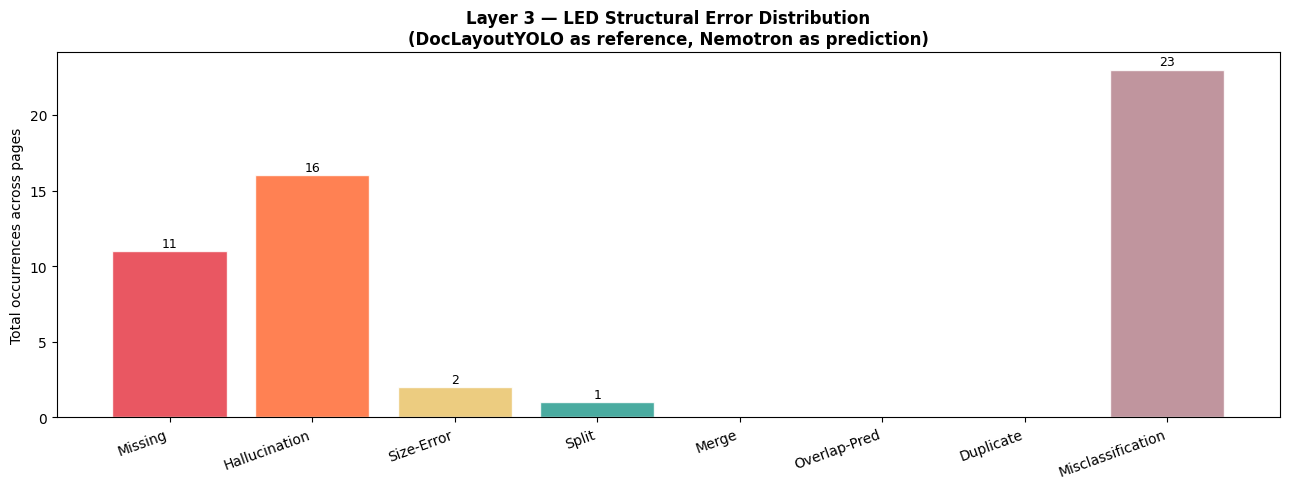


✅ Layer 3 LED classification complete


In [23]:
# ── CELL 15: Manual pipeline — Layer 3: LED structural errors ─
# Implements the 8 LED error types from the document:
#   Missing, Hallucination, Size-Error, Split, Merge,
#   Overlap, Duplicate, Misclassification
# Using DL detections as reference, NM as predicted.

import numpy as np
from scipy.optimize import linear_sum_assignment
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

IOU_MISS_THR   = 0.10   # below this = no match at all (Missing / Hallucination)
IOU_MATCH_THR  = 0.50   # solid match threshold
DUP_IOU_THR    = 0.85   # near-identical boxes → Duplicate


def classify_led_errors(ref_dets, pred_dets, page_w, page_h):
    """
    Classify each prediction and reference detection into LED error types.
    Returns dict of error_type → list of involved detection indices.
    """
    if not ref_dets or not pred_dets:
        return {}

    n_ref  = len(ref_dets)
    n_pred = len(pred_dets)
    iou_mat = np.zeros((n_ref, n_pred))
    for i, rd in enumerate(ref_dets):
        for j, pd in enumerate(pred_dets):
            iou_mat[i, j] = compute_iou(rd['bbox'], pd['bbox'])

    errors = defaultdict(list)

    # ── Duplicate: two pred boxes nearly identical ────────────
    for j1 in range(n_pred):
        for j2 in range(j1+1, n_pred):
            if compute_iou(pred_dets[j1]['bbox'],
                           pred_dets[j2]['bbox']) >= DUP_IOU_THR:
                errors['Duplicate'].append((j1, j2))

    # ── Missing (False Negative) ──────────────────────────────
    # Ref box with no pred overlapping at IoU ≥ 0.10
    for i in range(n_ref):
        if iou_mat[i].max() < IOU_MISS_THR:
            errors['Missing'].append(i)

    # ── Hallucination (False Positive) ────────────────────────
    for j in range(n_pred):
        if iou_mat[:, j].max() < IOU_MISS_THR:
            errors['Hallucination'].append(j)

    # ── Hungarian matching for remaining analysis ─────────────
    cost    = 1.0 - iou_mat
    ri, ci  = linear_sum_assignment(cost)
    matched_ref  = set()
    matched_pred = set()
    valid_matches = []
    for r, c in zip(ri, ci):
        if iou_mat[r, c] >= IOU_MISS_THR:
            matched_ref.add(r);  matched_pred.add(c)
            valid_matches.append((r, c, iou_mat[r, c]))

    # ── Misclassification: good IoU but wrong class ───────────
    for r, c, iou in valid_matches:
        if (iou >= IOU_MATCH_THR and
                ref_dets[r]['type'] != pred_dets[c]['type']):
            errors['Misclassification'].append((r, c))

    # ── Size Error: matched but IoU in [0.10, 0.50) ──────────
    for r, c, iou in valid_matches:
        if IOU_MISS_THR <= iou < IOU_MATCH_THR:
            errors['Size-Error'].append((r, c))

    # ── Split: one ref box matched by multiple pred boxes ─────
    ref_to_preds = defaultdict(list)
    for r, c, iou in valid_matches:
        ref_to_preds[r].append(c)
    # Also check unmatched preds that overlap a ref
    for j in range(n_pred):
        for i in range(n_ref):
            if iou_mat[i, j] >= IOU_MISS_THR and j not in matched_pred:
                ref_to_preds[i].append(j)
    for r, preds in ref_to_preds.items():
        if len(preds) > 1:
            errors['Split'].append((r, preds))

    # ── Merge: one pred box overlapping multiple ref boxes ────
    pred_to_refs = defaultdict(list)
    for r, c, iou in valid_matches:
        pred_to_refs[c].append(r)
    for i in range(n_ref):
        for j in range(n_pred):
            if iou_mat[i, j] >= IOU_MISS_THR and i not in matched_ref:
                pred_to_refs[j].append(i)
    for c, refs in pred_to_refs.items():
        if len(refs) > 1:
            errors['Merge'].append((c, refs))

    # ── Overlap: pred boxes significantly overlapping each other
    for j1 in range(n_pred):
        for j2 in range(j1+1, n_pred):
            iou_pp = compute_iou(pred_dets[j1]['bbox'],
                                  pred_dets[j2]['bbox'])
            if IOU_MISS_THR <= iou_pp < DUP_IOU_THR:
                errors['Overlap-Pred'].append((j1, j2))

    return dict(errors)


print('='*65)
print('  🏷️  LAYER 3 — LED STRUCTURAL ERROR CLASSIFICATION')
print('  8 error types | DL as reference, Nemotron as prediction')
print('='*65)

led_summary = defaultdict(int)   # error_type → total count across pages
led_per_page = {}

ERROR_TYPES = ['Missing','Hallucination','Size-Error','Split',
               'Merge','Overlap-Pred','Duplicate','Misclassification']

print(f'\n  {"Page":6s}', end='')
for e in ERROR_TYPES:
    print(f'  {e[:8]:>8s}', end='')
print()
print('  ' + '-'*6 + ('  ' + '-'*8) * len(ERROR_TYPES))

for pg in NEMOTRON_PAGES:
    dl_dets = docling_results.get(pg, [])
    nm_dets = nemotron_results.get(pg, [])
    img     = page_images[pg]
    pw, ph  = img.size
    if not dl_dets or not nm_dets:
        continue

    errors = classify_led_errors(dl_dets, nm_dets, pw, ph)
    led_per_page[pg] = errors

    print(f'  {pg:<6d}', end='')
    for e in ERROR_TYPES:
        cnt = len(errors.get(e, []))
        led_summary[e] += cnt
        flag = '⚠️' if cnt > 2 else ''
        print(f'  {cnt:>6d}{flag:2s}', end='')
    print()

print('\n  ' + '-'*6 + ('  ' + '-'*8) * len(ERROR_TYPES))
print(f'  {"TOTAL":<6s}', end='')
for e in ERROR_TYPES:
    print(f'  {led_summary[e]:>8d}', end='')
print()

# ── LED bar chart ─────────────────────────────────────────────
error_colors = {
    'Missing'         : '#e63946',
    'Hallucination'   : '#ff6b35',
    'Size-Error'      : '#e9c46a',
    'Split'           : '#2a9d8f',
    'Merge'           : '#457b9d',
    'Overlap-Pred'    : '#8ecae6',
    'Duplicate'       : '#6d6875',
    'Misclassification': '#b5838d',
}

fig, ax = plt.subplots(figsize=(13, 5))
x      = np.arange(len(ERROR_TYPES))
totals = [led_summary[e] for e in ERROR_TYPES]
bars   = ax.bar(x, totals,
                color=[error_colors[e] for e in ERROR_TYPES],
                alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(ERROR_TYPES, rotation=20, ha='right')
ax.set_ylabel('Total occurrences across pages')
ax.set_title('Layer 3 — LED Structural Error Distribution\n'
             '(DocLayoutYOLO as reference, Nemotron as prediction)',
             fontweight='bold')
for bar, v in zip(bars, totals):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/layer3_led_errors.png",
            dpi=120, bbox_inches='tight')
plt.show()

print('\n✅ Layer 3 LED classification complete')

  📖 LAYER 4 — READING ORDER EVALUATION
  ROKT (Kendall's Tau) + ROA per page

  Page    DL n    NM n    ROKT      ROA       Interpretation
  ------  ------  ------  --------  --------  ------------------------------
  7       10      10        1.0000    1.0000  ✅ strong agreement
  15      20      18        1.0000    1.0000  ✅ strong agreement
  17      5       4         1.0000    1.0000  ✅ strong agreement
  19      4       13           nan       nan  ❌ poor agreement
  25      14      15        1.0000    1.0000  ✅ strong agreement


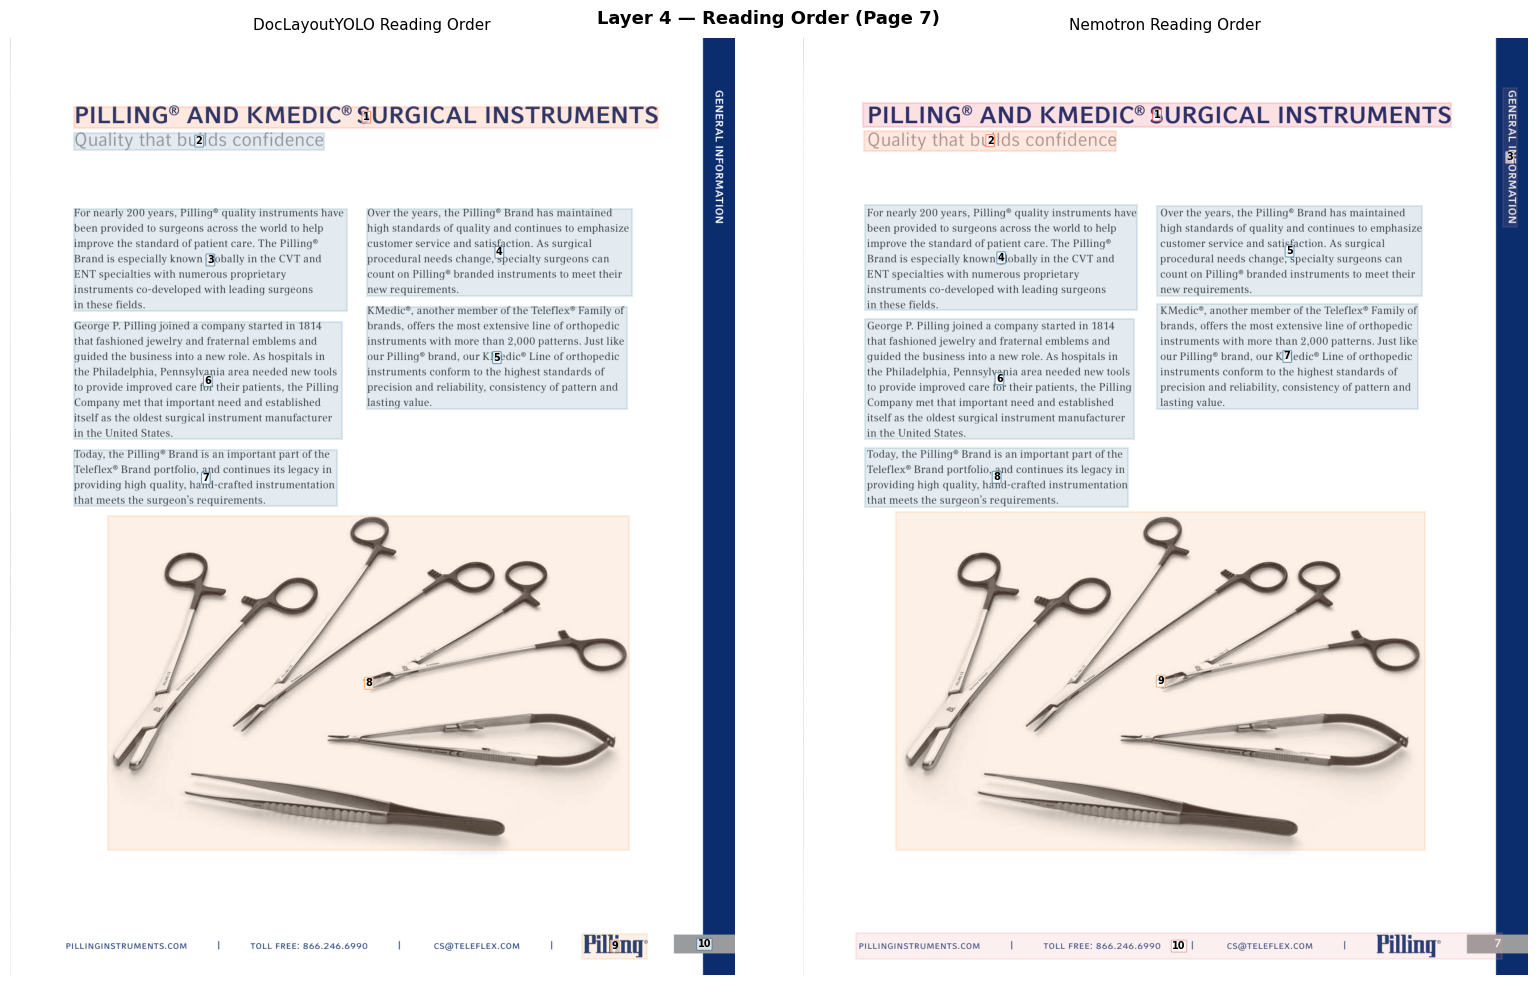


✅ Layer 4 reading order evaluation complete


In [24]:
# ── CELL 16: Manual pipeline — Layer 4: Reading Order ─────────
# Implements:
#   • Reading Order Kendall's Tau (ROKT) — rank correlation
#   • Segment Read Order Accuracy (ROA) — linear permutation error
# Reading order inferred geometrically:
#   primary sort: top-to-bottom (y centroid)
#   secondary sort: left-to-right (x centroid) within same row band

import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROW_BAND_PX = 40   # vertical tolerance to consider two boxes in same row


def assign_reading_order(detections, row_band=ROW_BAND_PX):
    """
    Assign a reading order index to each detection using
    top-to-bottom, left-to-right geometric heuristic.
    Returns list of (detection, order_index) sorted by reading order.
    """
    if not detections:
        return []
    # Compute centroids
    dets_with_cy = []
    for d in detections:
        x0,y0,x1,y1 = d['bbox']
        cx = (x0+x1)/2;  cy = (y0+y1)/2
        dets_with_cy.append((d, cx, cy))

    # Sort: group into row bands, then left-to-right within each band
    dets_with_cy.sort(key=lambda t: t[2])   # sort by cy first
    ordered = []
    current_band_y  = None
    current_band    = []

    for item in dets_with_cy:
        d, cx, cy = item
        if current_band_y is None or abs(cy - current_band_y) <= row_band:
            current_band.append(item)
            current_band_y = cy if current_band_y is None else (
                (current_band_y * (len(current_band)-1) + cy) / len(current_band)
            )
        else:
            current_band.sort(key=lambda t: t[1])   # sort by cx
            ordered.extend(current_band)
            current_band   = [item]
            current_band_y = cy

    if current_band:
        current_band.sort(key=lambda t: t[1])
        ordered.extend(current_band)

    return [(item[0], idx) for idx, item in enumerate(ordered)]


def kendalls_tau(order_a, order_b):
    """
    Compute Kendall's Tau between two reading orderings.
    order_a, order_b: lists of (detection_bbox_key, rank)
    Matched on bbox identity (same detection object).
    """
    # Build rank lookup by bbox tuple
    rank_a = {tuple(d['bbox']): r for d, r in order_a}
    rank_b = {tuple(d['bbox']): r for d, r in order_b}

    # Only compare detections present in both
    common_keys = set(rank_a.keys()) & set(rank_b.keys())
    if len(common_keys) < 2:
        return float('nan')

    keys = list(common_keys)
    C, D = 0, 0
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            a_diff = rank_a[keys[i]] - rank_a[keys[j]]
            b_diff = rank_b[keys[i]] - rank_b[keys[j]]
            if a_diff * b_diff > 0:
                C += 1
            elif a_diff * b_diff < 0:
                D += 1
    n = len(keys)
    denom = n * (n-1) / 2
    return (C - D) / denom if denom > 0 else float('nan')


def segment_roa(order_a, order_b):
    """
    Segment Read Order Accuracy: ROA = 1 - m/n
    m = blocks out of correct order, n = total blocks.
    """
    rank_a = {tuple(d['bbox']): r for d, r in order_a}
    rank_b = {tuple(d['bbox']): r for d, r in order_b}
    common = list(set(rank_a.keys()) & set(rank_b.keys()))
    if not common:
        return float('nan')
    # Sort by rank_a order, check if rank_b is also ascending
    common.sort(key=lambda k: rank_a[k])
    b_ranks = [rank_b[k] for k in common]
    # Count inversions
    m = sum(1 for i in range(len(b_ranks)-1)
            if b_ranks[i] > b_ranks[i+1])
    return 1.0 - m / max(len(common)-1, 1)


print('='*65)
print('  📖 LAYER 4 — READING ORDER EVALUATION')
print('  ROKT (Kendall\'s Tau) + ROA per page')
print('='*65)

ro_results = {}

print(f'\n  {"Page":6s}  {"DL n":6s}  {"NM n":6s}  {"ROKT":8s}  {"ROA":8s}  Interpretation')
print(f'  {"-"*6}  {"-"*6}  {"-"*6}  {"-"*8}  {"-"*8}  {"-"*30}')

for pg in NEMOTRON_PAGES:
    dl_dets = docling_results.get(pg, [])
    nm_dets = nemotron_results.get(pg, [])
    if not dl_dets or not nm_dets:
        continue

    dl_order = assign_reading_order(dl_dets)
    nm_order = assign_reading_order(nm_dets)

    # To compare across models we need matched detections
    # Use IoU ≥ 0.30 to find corresponding pairs
    iou_mat  = build_iou_matrix(dl_dets, nm_dets)
    matched_dl, matched_nm = [], []
    from scipy.optimize import linear_sum_assignment
    ri, ci = linear_sum_assignment(1.0 - iou_mat)
    for r, c in zip(ri, ci):
        if iou_mat[r, c] >= 0.30:
            matched_dl.append(dl_dets[r])
            matched_nm.append(nm_dets[c])

    # Build matched orderings using same indices
    dl_order_matched = assign_reading_order(matched_dl)
    nm_order_matched = assign_reading_order(matched_nm)

    # Re-key by position in matched list so tau can be computed
    dl_keyed = {i: r for i, (d, r) in enumerate(dl_order_matched)}
    nm_keyed = {i: r for i, (d, r) in enumerate(nm_order_matched)}

    # Kendall's tau on matched pair indices
    n = len(matched_dl)
    if n >= 2:
        C, D = 0, 0
        for i in range(n):
            for j in range(i+1, n):
                a_diff = dl_keyed[i] - dl_keyed[j]
                b_diff = nm_keyed[i] - nm_keyed[j]
                if a_diff * b_diff > 0:   C += 1
                elif a_diff * b_diff < 0: D += 1
        denom = n*(n-1)/2
        tau   = (C-D)/denom if denom > 0 else float('nan')
    else:
        tau = float('nan')

    # ROA on matched pairs
    b_ranks = [nm_keyed[i] for i in range(n)]
    m_inv   = sum(1 for i in range(len(b_ranks)-1)
                  if b_ranks[i] > b_ranks[i+1])
    roa     = 1.0 - m_inv / max(n-1, 1) if n > 1 else float('nan')

    ro_results[pg] = {'tau': tau, 'roa': roa,
                      'n_dl': len(dl_dets), 'n_nm': len(nm_dets),
                      'n_matched': n}

    interp = ('✅ strong agreement' if not np.isnan(tau) and tau > 0.7
              else '⚠️  partial disagreement' if not np.isnan(tau) and tau > 0.3
              else '❌ poor agreement')
    tau_str = f'{tau:.4f}' if not np.isnan(tau) else '   nan'
    roa_str = f'{roa:.4f}' if not np.isnan(roa) else '   nan'
    print(f'  {pg:<6d}  {len(dl_dets):<6d}  {len(nm_dets):<6d}  '
          f'{tau_str:>8s}  {roa_str:>8s}  {interp}')

# ── Visualise reading order on one page ───────────────────────
if ro_results:
    sample_pg = NEMOTRON_PAGES[0]
    dl_dets   = docling_results.get(sample_pg, [])
    nm_dets   = nemotron_results.get(sample_pg, [])
    orig_img  = page_images[sample_pg]

    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    fig.suptitle(f'Layer 4 — Reading Order (Page {sample_pg})',
                 fontsize=13, fontweight='bold')

    for ax, dets, title in [
        (axes[0], dl_dets, 'DocLayoutYOLO Reading Order'),
        (axes[1], nm_dets, 'Nemotron Reading Order'),
    ]:
        ax.imshow(orig_img)
        ordered = assign_reading_order(dets)
        for det, idx in ordered:
            x0,y0,x1,y1 = det['bbox']
            cx = (x0+x1)/2;  cy = (y0+y1)/2
            color = CANONICAL_COLORS.get(det['type'], '#888888')
            rect  = plt.Rectangle((x0,y0), x1-x0, y1-y0,
                                   linewidth=1.5, edgecolor=color,
                                   facecolor=color, alpha=0.15)
            ax.add_patch(rect)
            ax.text(cx, cy, str(idx+1), ha='center', va='center',
                    fontsize=7, fontweight='bold', color='black',
                    bbox=dict(boxstyle='round,pad=0.1',
                              facecolor='white', alpha=0.7,
                              edgecolor=color, linewidth=0.8))
        ax.set_title(title, fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/layer4_reading_order_p{sample_pg}.png",
                dpi=120, bbox_inches='tight')
    plt.show()

print('\n✅ Layer 4 reading order evaluation complete')

In [25]:
# ── CELL 17: Final consolidated evaluation report ─────────────

import json
from datetime import datetime

print('='*65)
print('  📋 CONSOLIDATED EVALUATION REPORT')
print(f'  Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'  Pages evaluated: {NEMOTRON_PAGES}')
print('='*65)

# ── Layer 1 summary ───────────────────────────────────────────
print('\n▶ LAYER 1 — Geometric Match (IoU-based, DL↔NM)')
if geo_results:
    thr = 0.5
    p_vals = [geo_results[pg][thr]['precision']  for pg in geo_results]
    r_vals = [geo_results[pg][thr]['recall']     for pg in geo_results]
    f_vals = [geo_results[pg][thr]['f1']         for pg in geo_results]
    i_vals = [geo_results[pg][thr]['mean_iou']   for pg in geo_results]
    c_vals = [geo_results[pg][thr]['class_acc']  for pg in geo_results]
    print(f'  IoU≥0.50  Precision={np.mean(p_vals):.3f}  '
          f'Recall={np.mean(r_vals):.3f}  F1={np.mean(f_vals):.3f}')
    print(f'            mean_IoU={np.mean(i_vals):.3f}  '
          f'ClassAccuracy={np.mean(c_vals):.3f}')

# ── Layer 2 summary ───────────────────────────────────────────
print('\n▶ LAYER 2 — COTe Spatial Quality (DL as SSU reference)')
if cote_results:
    for metric in ['Coverage','Overlap','Trespass','Excess']:
        vals = [cote_results[pg]['DL→NM'][metric] for pg in cote_results]
        flag = ''
        if metric == 'Coverage'  and np.mean(vals) < 0.5:  flag = '⚠️  low'
        if metric == 'Trespass'  and np.mean(vals) > 0.2:  flag = '⚠️  high'
        if metric == 'Overlap'   and np.mean(vals) > 0.2:  flag = '⚠️  high'
        print(f'  {metric:12s}: {np.mean(vals):.4f}  {flag}')

# ── Layer 3 summary ───────────────────────────────────────────
print('\n▶ LAYER 3 — LED Structural Errors (DL ref, NM pred)')
total_dets = sum(len(nemotron_results.get(pg,[])) for pg in NEMOTRON_PAGES)
for e in ERROR_TYPES:
    cnt  = led_summary[e]
    rate = cnt / max(total_dets, 1)
    flag = '⚠️' if rate > 0.10 else ''
    print(f'  {e:20s}: {cnt:3d}  ({rate*100:.1f}% of NM dets)  {flag}')

# ── Layer 4 summary ───────────────────────────────────────────
print('\n▶ LAYER 4 — Reading Order Agreement')
if ro_results:
    tau_vals = [v['tau'] for v in ro_results.values()
                if not np.isnan(v['tau'])]
    roa_vals = [v['roa'] for v in ro_results.values()
                if not np.isnan(v['roa'])]
    if tau_vals:
        print(f'  Mean ROKT (Kendall\'s Tau) : {np.mean(tau_vals):.4f}')
    if roa_vals:
        print(f'  Mean ROA                  : {np.mean(roa_vals):.4f}')

# ── Interpretation guide ──────────────────────────────────────
print('\n▶ INTERPRETATION GUIDE')
print('  Layer 1  F1 > 0.6              → good geometric agreement')
print('  Layer 2  Coverage > 0.7        → most regions well-covered')
print('           Trespass < 0.15       → boxes not bleeding into neighbours')
print('           Overlap  < 0.15       → minimal duplicate coverage')
print('  Layer 3  Missing/Hallu < 10%   → detection completeness healthy')
print('           Misclass < 10%        → class labels broadly consistent')
print('  Layer 4  ROKT > 0.7            → reading order strongly agreed')

# ── Save full report JSON ─────────────────────────────────────
report = {
    'generated'      : datetime.now().isoformat(),
    'pages'          : NEMOTRON_PAGES,
    'layer1_geo'     : {
        pg: {str(thr): v for thr, v in res.items()
             if thr != 'matches'}
        for pg, res in geo_results.items()
    },
    'layer2_cote'    : {str(pg): v for pg, v in cote_results.items()},
    'layer3_led'     : {str(pg): {k: len(v) for k, v in errors.items()}
                        for pg, errors in led_per_page.items()},
    'layer4_ro'      : {str(pg): {k: (float(v) if not isinstance(v, int) else v)
                                   for k, v in res.items()}
                        for pg, res in ro_results.items()},
}

report_path = f"{CONFIG['output_dir']}/evaluation_report.json"
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)

print(f'\n✅ Full report saved → {report_path}')
print('='*65)

  📋 CONSOLIDATED EVALUATION REPORT
  Generated: 2026-06-08 06:08
  Pages evaluated: [7, 15, 17, 19, 25]

▶ LAYER 1 — Geometric Match (IoU-based, DL↔NM)
  IoU≥0.50  Precision=0.626  Recall=0.636  F1=0.620
            mean_IoU=0.817  ClassAccuracy=0.392

▶ LAYER 2 — COTe Spatial Quality (DL as SSU reference)
  Coverage    : 0.6917  
  Overlap     : 0.0000  
  Trespass    : 0.0006  
  Excess      : 0.0582  

▶ LAYER 3 — LED Structural Errors (DL ref, NM pred)
  Missing             :  11  (18.3% of NM dets)  ⚠️
  Hallucination       :  16  (26.7% of NM dets)  ⚠️
  Size-Error          :   2  (3.3% of NM dets)  
  Split               :   1  (1.7% of NM dets)  
  Merge               :   0  (0.0% of NM dets)  
  Overlap-Pred        :   0  (0.0% of NM dets)  
  Duplicate           :   0  (0.0% of NM dets)  
  Misclassification   :  23  (38.3% of NM dets)  ⚠️

▶ LAYER 4 — Reading Order Agreement
  Mean ROKT (Kendall's Tau) : 1.0000
  Mean ROA                  : 1.0000

▶ INTERPRETATION GUIDE
  L